# 🥦 EDA Dataset Sayur & Buah
Pertanyaan:
1. Produk apa saja yang justru mengalami penurunan kualitas jika disimpan di suhu dingin?
2. Kategori (`item_type`) mana yang paling rentan rusak secara biologis?
3. Apakah tingkat respirasi tinggi selalu berbanding lurus dengan umur simpan yang pendek?
4. Bisakah kita memprediksi durasi penyimpanan di kulkas berdasarkan kadar air?
5. Apakah item yang sensitif terhadap dingin memiliki kadar air yang lebih rendah secara rata-rata?
6. Bagaimana distribusi umur simpan suhu ruang untuk produk "High Respiration"?
7. Produk mana yang memiliki risiko food waste tertinggi (umur simpan < 3 hari di suhu ruang)?
8. Seberapa besar "kerugian" umur simpan yang terjadi jika produk sensitif dingin tetap dimasukkan ke kulkas?
9. Kategori produk mana yang paling cocok diprioritaskan untuk sistem FIFO dalam inventaris?
10. Apakah produk penghasil etilen (ethylene producer) memiliki umur simpan yang lebih pendek?
11. Bagaimana peta risiko produk berdasarkan kadar air dan laju respirasi?
12. Produk apa yang paling stabil dan cocok untuk stok buffer jangka panjang?

## Setup & Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Tema Visualisasi ──
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

PALETTE_MAIN = "viridis"
PALETTE_DIV  = "coolwarm"
COLOR_ACCENT = "#2196F3"
COLOR_WARN   = "#FF5722"
COLOR_OK     = "#4CAF50"
COLOR_NEU    = "#9E9E9E"

print("✅ Library berhasil dimuat.")

✅ Library berhasil dimuat.


## Load & Validasi Data

In [3]:
df_clean = pd.read_csv('../../dataset/clean/sayur_buah_clean_v1.csv')

print(f"Shape dataset: {df_clean.shape}")
df_clean.head(10)

Shape dataset: (304, 9)


,item_name,item_type,freshness_score_visual,standard_shelf_life_fridge,standard_shelf_life_room,water_content_pct,ethylene_producer,respiration_rate,sensitivity_to_chilling
0,Stroberi,Berry,0.58,5.0,1.0,89.50000,False,tinggi,False
1,Sawi Hijau,Leafy Vegetable,0.82,5.0,0.0,86.36295,False,tinggi,False
2,Lemon,Unknown,0.86,20.0,6.0,89.40000,False,rendah,False
3,Pisang,Tropical Fruit,0.64,4.0,2.0,86.36295,True,tinggi,True
4,Sawi Hijau,Leafy Vegetable,0.81,5.0,1.0,91.20000,False,tinggi,False
5,Pepaya,Tropical Fruit,0.69,4.0,2.0,88.00000,True,tinggi,True
6,Anggur,Temperate Fruit,0.73,6.0,3.0,82.10000,True,tinggi,False
7,Bawang Putih,Root Veg,0.89,92.0,44.0,63.50000,False,rendah,False
8,Sawi Hijau,Leafy Vegetable,0.81,4.0,1.0,92.80000,False,tinggi,False
9,Melon,Tropical Fruit,0.74,7.0,2.0,90.20000,True,sedang,True


In [4]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   item_name                   304 non-null    object 
 1   item_type                   304 non-null    object 
 2   freshness_score_visual      304 non-null    float64
 3   standard_shelf_life_fridge  304 non-null    float64
 4   standard_shelf_life_room    304 non-null    float64
 5   water_content_pct           304 non-null    float64
 6   ethylene_producer           304 non-null    bool   
 7   respiration_rate            304 non-null    object 
 8   sensitivity_to_chilling     304 non-null    bool   
dtypes: bool(2), float64(4), object(3)
memory usage: 17.3+ KB


In [5]:
df_clean.duplicated().sum()

0

In [6]:
df_clean.isnull().sum()

item_name                     0
item_type                     0
freshness_score_visual        0
standard_shelf_life_fridge    0
standard_shelf_life_room      0
water_content_pct             0
ethylene_producer             0
respiration_rate              0
sensitivity_to_chilling       0
dtype: int64

In [7]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_name,304,43,Stroberi,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_type,304,36,Tropical Fruit,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freshness_score_visual,304.0,NaN,NaN,NaN,1.878145,9.718378,-0.5,0.74,0.84,0.89,99.0
standard_shelf_life_fridge,304.0,NaN,NaN,NaN,18.207358,22.076909,0.0,6.0,12.0,20.0,98.0
standard_shelf_life_room,304.0,NaN,NaN,NaN,6.910653,9.982109,0.0,2.0,4.0,6.0,51.0
water_content_pct,304.0,NaN,NaN,NaN,86.36295,6.747362,61.4,85.1,87.7,90.225,97.0
ethylene_producer,304,2,False,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
respiration_rate,304,3,rendah,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_to_chilling,304,2,False,231,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Normalisasi Data

In [8]:
type_map = {
    'berry': 'Berry', 'beri': 'Berry', 'berries': 'Berry', 'berrys': 'Berry',
    'tropical fruit': 'Tropical Fruit', 'buah tropis': 'Tropical Fruit',
    'tropis': 'Tropical Fruit', 'tropical': 'Tropical Fruit',
    'leafy vegetable': 'Leafy Vegetable', 'sayur daun': 'Leafy Vegetable',
    'leafy vegetable': 'Leafy Vegetable', 'leafy vegetable': 'Leafy Vegetable',
    'root vegetable': 'Root Vegetable', 'root veg': 'Root Vegetable',
    'sayur akar': 'Root Vegetable', 'akar-akaran': 'Root Vegetable',
    'temperate fruit': 'Temperate Fruit', 'buah sedang': 'Temperate Fruit',
    'temperate': 'Temperate Fruit',
    'citric fruit': 'Citrus Fruit', 'citrus': 'Citrus Fruit',
    'citric': 'Citrus Fruit', 'buah citrus': 'Citrus Fruit',
    'chili': 'Chili', 'chile': 'Chili', 'cabai': 'Chili',
    'unknown': 'Unknown',
}

df = df_clean.copy()
df['item_type'] = df['item_type'].str.strip().str.lower().map(type_map).fillna(df['item_type'].str.strip())

print("Distribusi item_type setelah normalisasi:")
print(df['item_type'].value_counts().to_string())

Distribusi item_type setelah normalisasi:
item_type
Tropical Fruit     78
Root Vegetable     55
Leafy Vegetable    54
Citrus Fruit       29
Temperate Fruit    27
Unknown            24
Berry              19
Chili              18


## Deteksi & Penanganan Outlier

In [9]:
numeric_cols = [
    'freshness_score_visual',
    'standard_shelf_life_fridge',
    'standard_shelf_life_room',
    'water_content_pct'
]

def check_outliers_iqr(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n = ((df[col] < lo) | (df[col] > hi)).sum()
        rows.append({
            'Kolom': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'Lower Bound': round(lo, 2), 'Upper Bound': round(hi, 2),
            'Jumlah Outlier': n, 'Persen (%)': f"{n/len(df)*100:.1f}%"
        })
    return pd.DataFrame(rows)

outlier_df = check_outliers_iqr(df, numeric_cols)
print("Ringkasan Outlier (Metode IQR):")
outlier_df

Ringkasan Outlier (Metode IQR):


,Kolom,Q1,Q3,Lower Bound,Upper Bound,Jumlah Outlier,Persen (%)
0,freshness_score_visual,0.74,0.89,0.51,1.11,36,11.8%
1,standard_shelf_life_fridge,6.00,20.00,-15.00,41.00,30,9.9%
2,standard_shelf_life_room,2.00,6.00,-4.00,12.00,33,10.9%
3,water_content_pct,85.10,90.22,77.41,97.91,28,9.2%


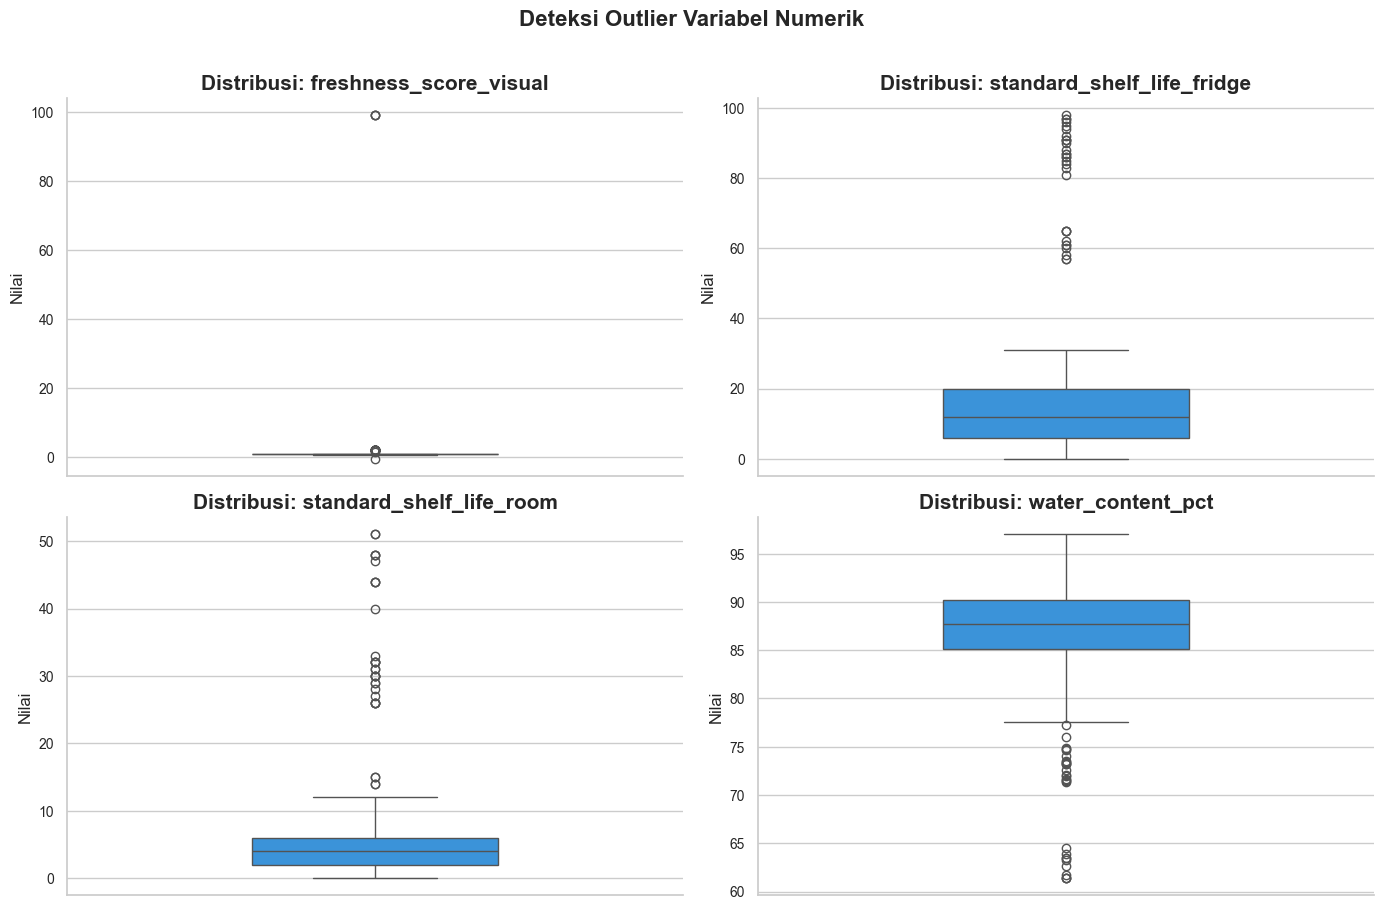

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=COLOR_ACCENT, width=0.4)
    axes[i].set_title(f"Distribusi: {col}", fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Deteksi Outlier Variabel Numerik', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Capping Outlier dengan IQR Method 
def cap_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR 
    before = df[col].copy()
    df[col] = df[col].clip(lower=lo, upper=hi)
    n_capped = (before != df[col]).sum()
    print(f"  [{col}] {n_capped} nilai di-cap → range [{lo:.2f}, {hi:.2f}]")
    return df

print("🔧 Capping outlier pada freshness_score_visual:")
df = cap_outliers_iqr(df, 'freshness_score_visual')
print(f"  Nilai maks setelah capping: {df['freshness_score_visual'].max():.3f}")

🔧 Capping outlier pada freshness_score_visual:
  [freshness_score_visual] 36 nilai di-cap → range [0.51, 1.11]
  Nilai maks setelah capping: 1.115


## 5️⃣ Feature Engineering & Binning

In [12]:
# inning Umur Simpan Suhu Ruang (Risiko Food Waste) 
bins_room   = [0, 3, 7, df['standard_shelf_life_room'].max() + 0.1]
labels_room = ['Short-Lived (<3 hari)', 'Medium (3-7 hari)', 'Stable (>7 hari)']
df['shelf_life_category'] = pd.cut(df['standard_shelf_life_room'], bins=bins_room, labels=labels_room)

# Binning Kadar Air
bins_water   = [0, 80, 90, 100]
labels_water = ['Low (<80%)', 'Medium (80-90%)', 'High >90% (Perishable)']
df['water_content_category'] = pd.cut(df['water_content_pct'], bins=bins_water, labels=labels_water)

# Binning Skor Kesegaran Visual 
bins_fresh   = [-np.inf, 0.6, 0.8, np.inf]
labels_fresh = ['Priority Sale', 'Monitor', 'Excellent']
df['freshness_status'] = pd.cut(df['freshness_score_visual'], bins=bins_fresh, labels=labels_fresh)

# Label Risiko Gabungan
def composite_waste_risk(row):
    risk = 0
    if row['standard_shelf_life_room'] < 3:   risk += 2
    elif row['standard_shelf_life_room'] < 7:  risk += 1
    if row['respiration_rate'] == 'tinggi':    risk += 1
    if row['water_content_pct'] > 90:          risk += 1
    if risk >= 3: return 'HIGH Risk'
    elif risk == 2: return 'MEDIUM Risk'
    else:           return 'LOW Risk'

df['waste_risk_label'] = df.apply(composite_waste_risk, axis=1)

print("Feature engineering selesai. Kolom baru:")
new_cols = ['shelf_life_category', 'water_content_category', 'freshness_status', 'waste_risk_label']
print(df[['item_name'] + new_cols].head(10).to_string(index=False))

Feature engineering selesai. Kolom baru:
   item_name   shelf_life_category water_content_category freshness_status waste_risk_label
    Stroberi Short-Lived (<3 hari)        Medium (80-90%)    Priority Sale        HIGH Risk
  Sawi Hijau                   NaN        Medium (80-90%)        Excellent        HIGH Risk
       Lemon     Medium (3-7 hari)        Medium (80-90%)        Excellent         LOW Risk
      Pisang Short-Lived (<3 hari)        Medium (80-90%)          Monitor        HIGH Risk
  Sawi Hijau Short-Lived (<3 hari) High >90% (Perishable)        Excellent        HIGH Risk
      Pepaya Short-Lived (<3 hari)        Medium (80-90%)          Monitor        HIGH Risk
      Anggur Short-Lived (<3 hari)        Medium (80-90%)          Monitor      MEDIUM Risk
Bawang Putih      Stable (>7 hari)             Low (<80%)        Excellent         LOW Risk
  Sawi Hijau Short-Lived (<3 hari) High >90% (Perishable)        Excellent        HIGH Risk
       Melon Short-Lived (<3 hari) High

## Analisis Univariat

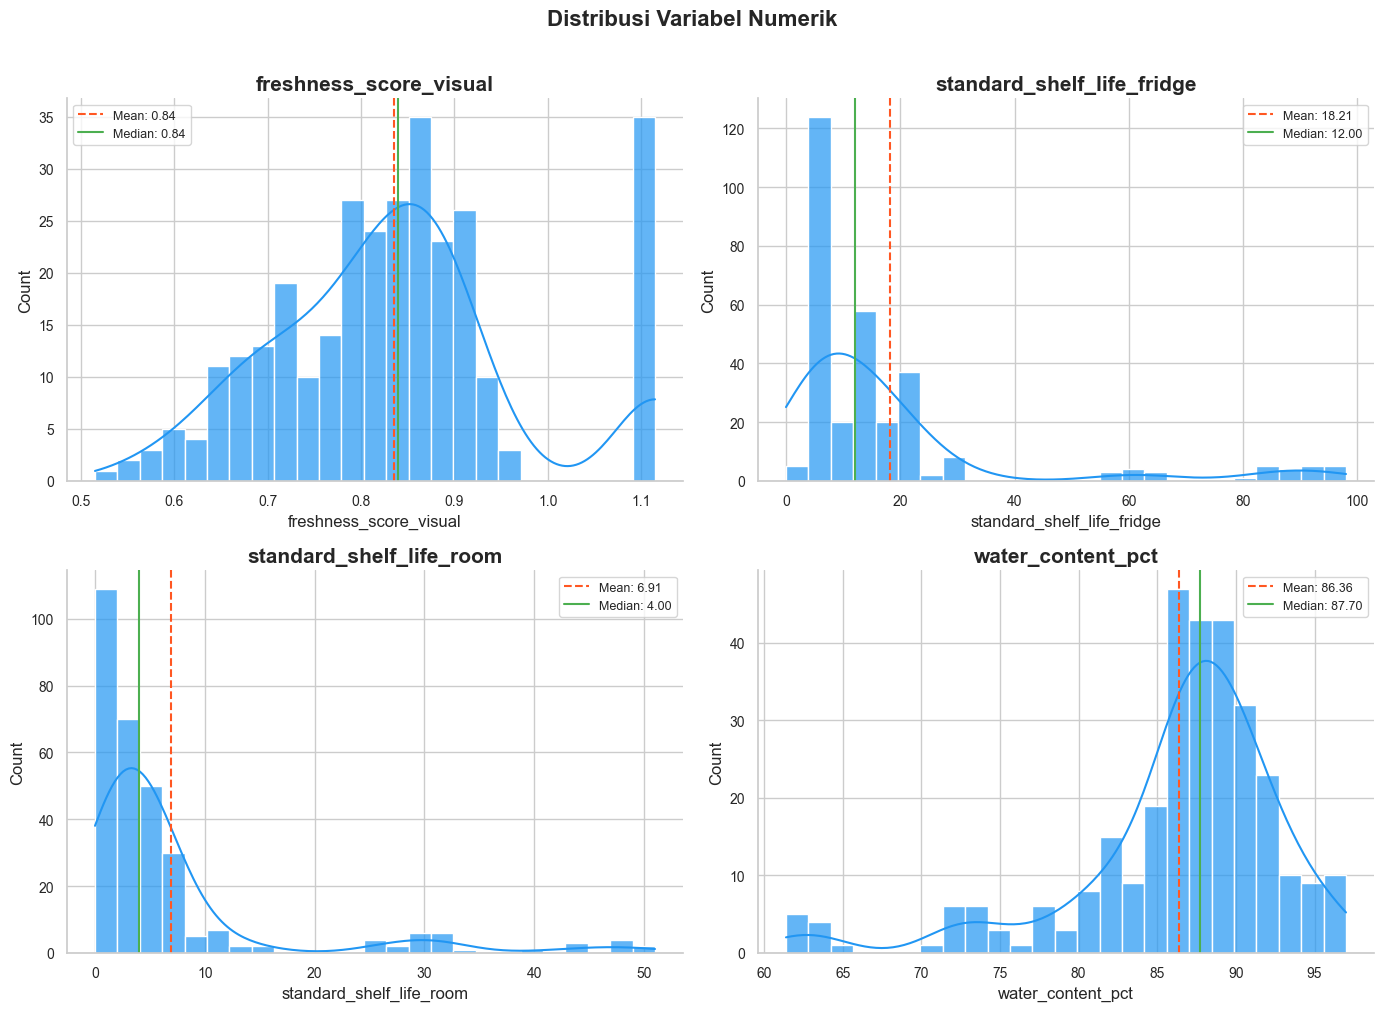

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=COLOR_ACCENT, bins=25, alpha=0.7)
    ax.axvline(df[col].mean(),   color=COLOR_WARN, linestyle='--', lw=1.5, label=f"Mean: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color=COLOR_OK,   linestyle='-',  lw=1.5, label=f"Median: {df[col].median():.2f}")
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Variabel Numerik', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

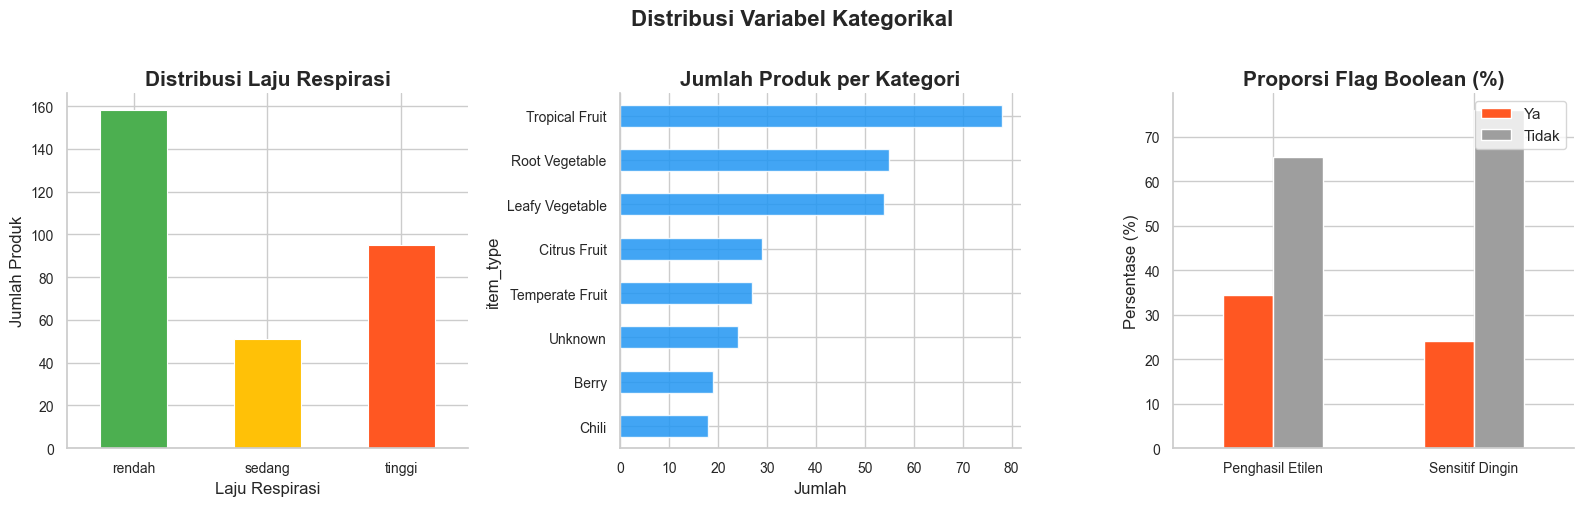

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi respiration_rate
rate_order = ['rendah', 'sedang', 'tinggi']
colors_rate = [COLOR_OK, '#FFC107', COLOR_WARN]
df['respiration_rate'].value_counts().reindex(rate_order).plot.bar(
    ax=axes[0], color=colors_rate, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Laju Respirasi', fontweight='bold')
axes[0].set_xlabel('Laju Respirasi')
axes[0].set_ylabel('Jumlah Produk')
axes[0].tick_params(axis='x', rotation=0)

# Distribusi item_type
type_counts = df['item_type'].value_counts()
type_counts.plot.barh(ax=axes[1], color=COLOR_ACCENT, alpha=0.85)
axes[1].set_title('Jumlah Produk per Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah')
axes[1].invert_yaxis()

# Boolean flags
bool_data = pd.DataFrame({
    'Penghasil Etilen': df['ethylene_producer'].value_counts(normalize=True).reindex([True, False]) * 100,
    'Sensitif Dingin':  df['sensitivity_to_chilling'].value_counts(normalize=True).reindex([True, False]) * 100,
})
bool_data.index = ['Ya', 'Tidak']
bool_data.T.plot.bar(ax=axes[2], color=[COLOR_WARN, COLOR_NEU], edgecolor='white')
axes[2].set_title('Proporsi Flag Boolean (%)', fontweight='bold')
axes[2].set_ylabel('Persentase (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='', loc='upper right')

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

## Analisis Bivariat

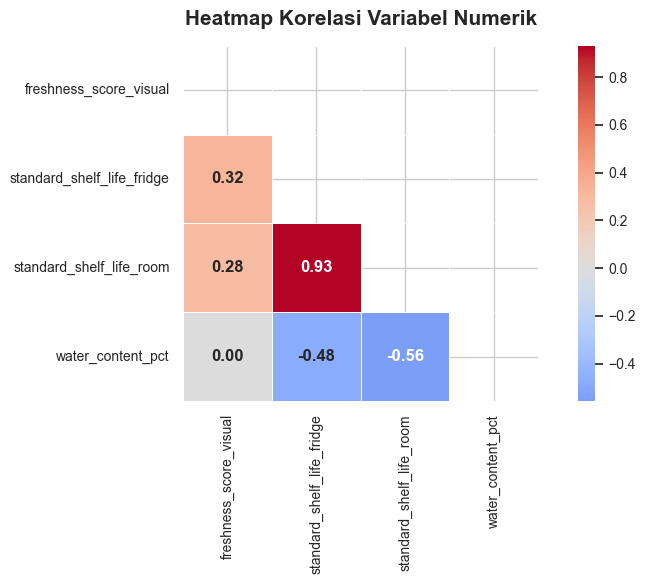

Insight
freshness_score_visual vs shelf_life_fridge: 0.325
water_content_pct vs shelf_life_fridge: -0.476
shelf_life_room s shelf_life_fridge: 0.932


In [15]:
# ── Heatmap Korelasi ────────────────────────────────────────────────────────
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=PALETTE_DIV,
            mask=mask, center=0, square=True, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Insight")
print("freshness_score_visual vs shelf_life_fridge:", round(corr_matrix.loc['freshness_score_visual','standard_shelf_life_fridge'], 3))
print("water_content_pct vs shelf_life_fridge:", round(corr_matrix.loc['water_content_pct','standard_shelf_life_fridge'], 3))
print("shelf_life_room s shelf_life_fridge:", round(corr_matrix.loc['standard_shelf_life_room','standard_shelf_life_fridge'], 3))

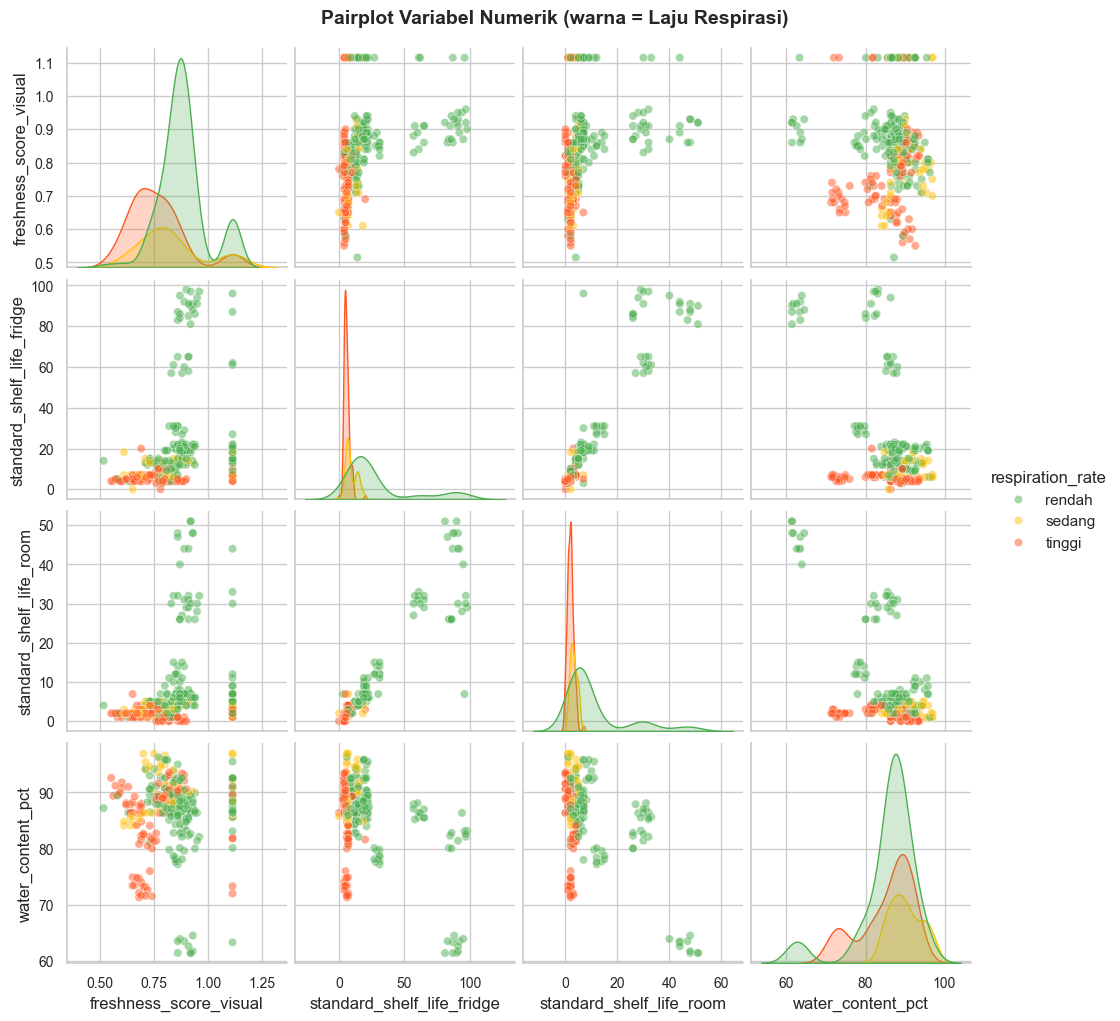

In [16]:
fig = sns.pairplot(
    df[numeric_cols + ['respiration_rate']],
    hue='respiration_rate',
    hue_order=['rendah', 'sedang', 'tinggi'],
    palette={'rendah': COLOR_OK, 'sedang': '#FFC107', 'tinggi': COLOR_WARN},
    diag_kind='kde', plot_kws={'alpha': 0.5}
)
fig.figure.suptitle('Pairplot Variabel Numerik (warna = Laju Respirasi)',
                    fontsize=14, y=1.02, fontweight='bold')
plt.show()

## Q1: Produk yang Mengalami Penurunan Kualitas di Suhu Dingin

In [17]:
cold_sensitive = df[df['sensitivity_to_chilling'] == True].copy()

# Rata-rata umur simpan per produk sensitif dingin
q1_summary = (
    cold_sensitive.groupby('item_name', observed=True)
    .agg(
        item_type=('item_type', 'first'),
        avg_shelf_life_fridge=('standard_shelf_life_fridge', 'mean'),
        avg_shelf_life_room=('standard_shelf_life_room', 'mean'),
        n=('item_name', 'count')
    )
    .reset_index()
    .sort_values('avg_shelf_life_fridge')
)

print(f"Jumlah produk sensitif dingin : {cold_sensitive['item_name'].nunique()} produk")
print(f"Total baris                   : {len(cold_sensitive)}")
print()
print(q1_summary.to_string(index=False))

Jumlah produk sensitif dingin : 10 produk
Total baris                   : 73

  item_name      item_type  avg_shelf_life_fridge  avg_shelf_life_room  n
    Pisang  Tropical Fruit               4.000000             2.000000  1
     Pepaya Tropical Fruit               4.444444             1.444444  9
     Pisang Tropical Fruit               4.444444             1.555556  9
     Nanas  Tropical Fruit               6.000000             3.000000  1
    Alpukat Tropical Fruit               6.500000             2.125000  8
      Nanas Tropical Fruit               6.500000             2.500000  8
      Melon Tropical Fruit               6.600000             2.991065 10
     Mangga Tropical Fruit               6.700000             3.700000 10
Cabai Hijau          Chili              13.800000             4.600000 10
Cabai Merah          Chili              13.857143             4.571429  7


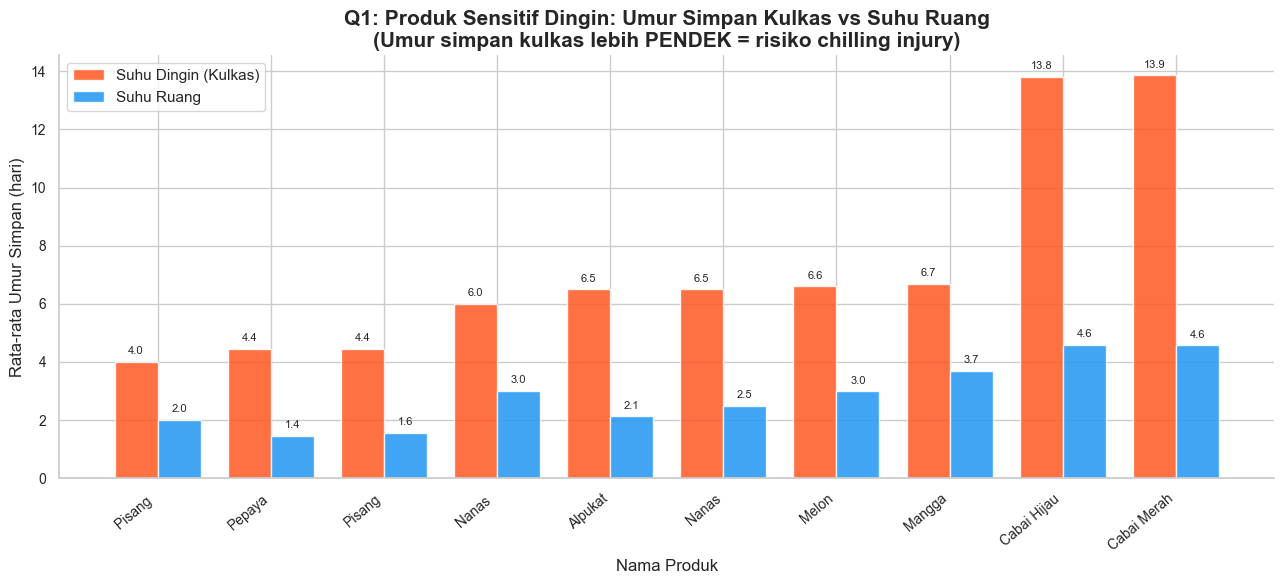

Insight:
Produk seperti Pisang, Pepaya, Mangga, Alpukat & Melon adalah buah tropis yang
TIDAK disarankan disimpan di kulkas — mempercepat kerusakan, bukan memperlambat.


In [42]:
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(q1_summary))
w = 0.38
bar1 = ax.bar(x - w/2, q1_summary['avg_shelf_life_fridge'], w,
              label='Suhu Dingin (Kulkas)', color=COLOR_WARN,   alpha=0.85)
bar2 = ax.bar(x + w/2, q1_summary['avg_shelf_life_room'],   w,
              label='Suhu Ruang',            color=COLOR_ACCENT, alpha=0.85)

# Annotate
for bar in [bar1, bar2]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.2, f'{h:.1f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(q1_summary['item_name'], rotation=40, ha='right')
ax.set_xlabel('Nama Produk')
ax.set_ylabel('Rata-rata Umur Simpan (hari)')
ax.set_title('Q1: Produk Sensitif Dingin: Umur Simpan Kulkas vs Suhu Ruang\n'
             '(Umur simpan kulkas lebih PENDEK = risiko chilling injury)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Insight:")
print("Produk seperti Pisang, Pepaya, Mangga, Alpukat & Melon adalah buah tropis yang")
print("TIDAK disarankan disimpan di kulkas — mempercepat kerusakan, bukan memperlambat.")

## Q2: Kategori yang Paling Rentan Rusak Secara Biologis

In [19]:
# Skor kerentanan biologis: tinggi respirasi + umur pendek + kadar air tinggi
bio_risk = df.groupby('item_type', observed=True).agg(
    avg_room_shelf   =('standard_shelf_life_room',   'mean'),
    avg_fridge_shelf =('standard_shelf_life_fridge', 'mean'),
    avg_water_pct    =('water_content_pct',          'mean'),
    pct_high_resp    =('respiration_rate',            lambda x: (x == 'tinggi').mean() * 100),
    pct_chilling_sens=('sensitivity_to_chilling',    'mean'),
    n                =('item_name',                  'count')
).reset_index().sort_values('avg_room_shelf')

print("=== Kerentanan Biologis per Kategori ===")
bio_risk.round(2)

=== Kerentanan Biologis per Kategori ===


,item_type,avg_room_shelf,avg_fridge_shelf,avg_water_pct,pct_high_resp,pct_chilling_sens,n
3,Leafy Vegetable,1.92,7.45,91.15,59.26,0.00,54
0,Berry,1.95,5.59,88.14,47.37,0.00,19
6,Tropical Fruit,2.68,7.29,85.17,50.00,0.69,78
5,Temperate Fruit,4.40,13.52,83.88,33.33,0.00,27
1,Chili,4.50,13.78,88.74,0.00,0.83,18
2,Citrus Fruit,5.68,18.12,87.81,0.00,0.00,29
7,Unknown,9.00,23.21,86.45,25.00,0.17,24
4,Root Vegetable,21.28,50.22,82.39,0.00,0.00,55


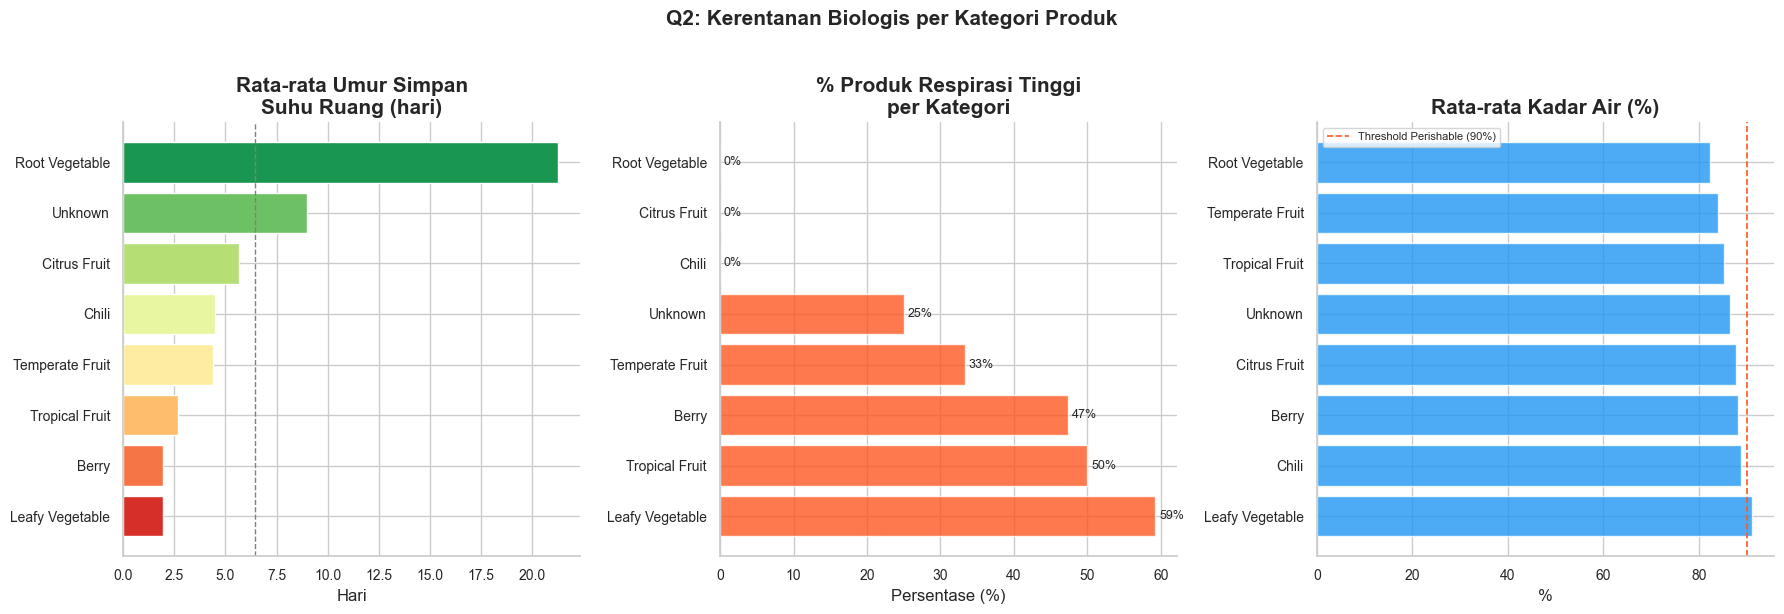

Insight:
  Kategori paling rentan (umur simpan terpendek): Leafy Vegetable, Berry, Tropical Fruit


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Umur simpan suhu ruang
bio_sorted = bio_risk.sort_values('avg_room_shelf')
axes[0].barh(bio_sorted['item_type'], bio_sorted['avg_room_shelf'],
             color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(bio_sorted))))
axes[0].set_title('Rata-rata Umur Simpan\nSuhu Ruang (hari)', fontweight='bold')
axes[0].set_xlabel('Hari')
axes[0].axvline(bio_sorted['avg_room_shelf'].mean(), color='gray', linestyle='--', lw=1)

# % Respirasi Tinggi
bio_sorted2 = bio_risk.sort_values('pct_high_resp', ascending=False)
bars = axes[1].barh(bio_sorted2['item_type'], bio_sorted2['pct_high_resp'],
                    color=COLOR_WARN, alpha=0.8)
axes[1].set_title('% Produk Respirasi Tinggi\nper Kategori', fontweight='bold')
axes[1].set_xlabel('Persentase (%)')
for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{w:.0f}%', va='center', fontsize=9)

# Kadar Air
bio_sorted3 = bio_risk.sort_values('avg_water_pct', ascending=False)
axes[2].barh(bio_sorted3['item_type'], bio_sorted3['avg_water_pct'],
             color=COLOR_ACCENT, alpha=0.8)
axes[2].set_title('Rata-rata Kadar Air (%)', fontweight='bold')
axes[2].set_xlabel('%')
axes[2].axvline(90, color=COLOR_WARN, linestyle='--', lw=1.2, label='Threshold Perishable (90%)')
axes[2].legend(fontsize=8)

plt.suptitle('Q2: Kerentanan Biologis per Kategori Produk', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
most_vulnerable = bio_risk.nsmallest(3, 'avg_room_shelf')['item_type'].tolist()
print(f"  Kategori paling rentan (umur simpan terpendek): {', '.join(most_vulnerable)}")

## Q3: Apakah Respirasi Tinggi Selalu Berarti Umur Simpan Pendek?

In [44]:
rate_order = ['rendah', 'sedang', 'tinggi']

q3_stats = df.groupby('respiration_rate', observed=True).agg(
    avg_room  =('standard_shelf_life_room',   'mean'),
    med_room  =('standard_shelf_life_room',   'median'),
    avg_fridge=('standard_shelf_life_fridge', 'mean'),
    med_fridge=('standard_shelf_life_fridge', 'median'),
    n         =('item_name',                  'count')
).reindex(rate_order)

print(q3_stats.round(2).to_string())

                  avg_room  med_room  avg_fridge  med_fridge    n
respiration_rate                                                 
rendah               11.20       6.0       28.65        19.0  158
sedang                3.10       3.0        9.21         7.0   51
tinggi                1.82       2.0        5.66         5.0   95


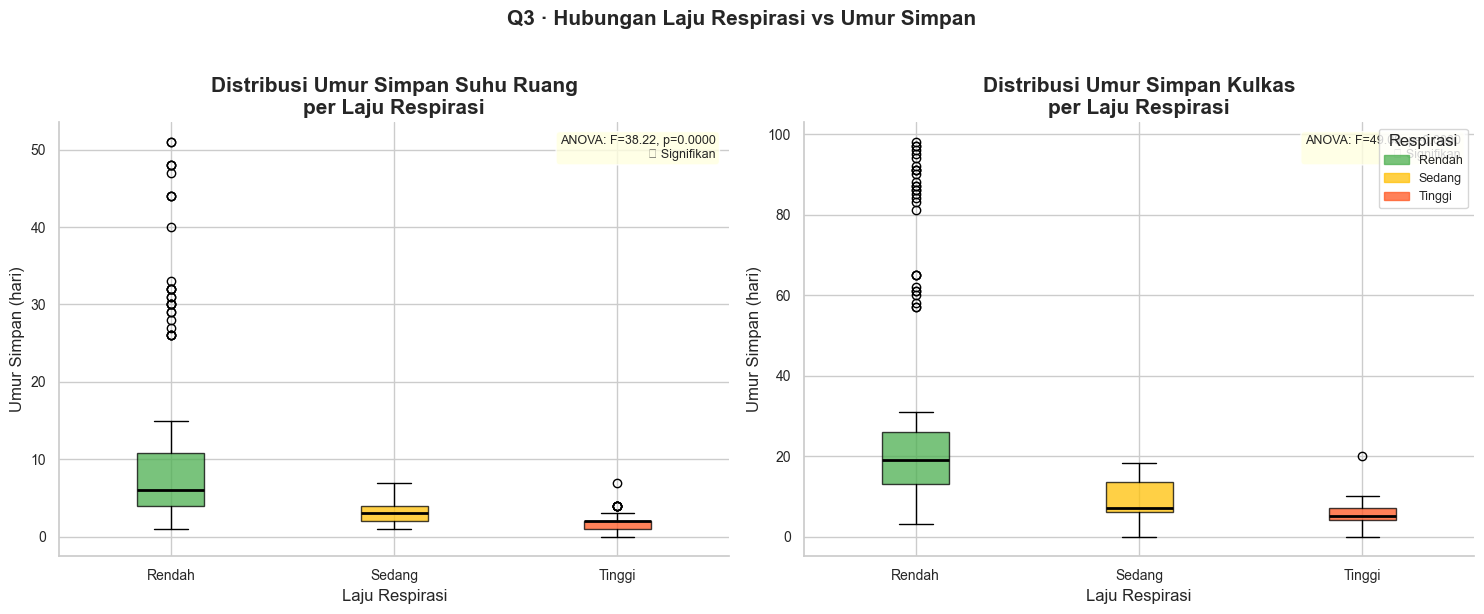

Insight:
Respirasi tinggi CENDERUNG berkorelasi dengan umur simpan yang lebih pendek,
namun ada overlap — terutama pada produk suhu dingin. Uji ANOVA di atas
mengkonfirmasi apakah perbedaan antar kelompok signifikan secara statistik.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_resp = {'rendah': COLOR_OK, 'sedang': '#FFC107', 'tinggi': COLOR_WARN}

for i, col in enumerate(['standard_shelf_life_room', 'standard_shelf_life_fridge']):
    ax = axes[i]
    groups = [df[df['respiration_rate'] == r][col].dropna() for r in rate_order]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, r in zip(bp['boxes'], rate_order):
        patch.set_facecolor(colors_resp[r])
        patch.set_alpha(0.75)
    ax.set_xticklabels([r.capitalize() for r in rate_order])
    ax.set_xlabel('Laju Respirasi')
    ax.set_ylabel('Umur Simpan (hari)')
    label = 'Suhu Ruang' if 'room' in col else 'Kulkas'
    ax.set_title(f'Distribusi Umur Simpan {label}\nper Laju Respirasi', fontweight='bold')

    # ANOVA test
    f_stat, p_val = stats.f_oneway(*groups)
    significance = "✅ Signifikan" if p_val < 0.05 else "Tidak Signifikan"
    ax.text(0.98, 0.97, f'ANOVA: F={f_stat:.2f}, p={p_val:.4f}\n{significance}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Legend
patches = [mpatches.Patch(color=c, label=r.capitalize(), alpha=0.75)
           for r, c in colors_resp.items()]
axes[1].legend(handles=patches, title='Respirasi', loc='upper right', fontsize=9)

plt.suptitle('Q3 · Hubungan Laju Respirasi vs Umur Simpan', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
print("Respirasi tinggi CENDERUNG berkorelasi dengan umur simpan yang lebih pendek,")
print("namun ada overlap — terutama pada produk suhu dingin. Uji ANOVA di atas")
print("mengkonfirmasi apakah perbedaan antar kelompok signifikan secara statistik.")

## Q4: Prediksi Durasi Penyimpanan Kulkas Berdasarkan Kadar Air

In [46]:
from scipy.stats import pearsonr, spearmanr

x = df['water_content_pct']
y = df['standard_shelf_life_fridge']

r_pearson, p_pearson   = pearsonr(x, y)
r_spearman, p_spearman = spearmanr(x, y)

print(f"Korelasi Pearson  : r = {r_pearson:.3f},  p = {p_pearson:.4f}")
print(f"Korelasi Spearman : r = {r_spearman:.3f},  p = {p_spearman:.4f}")

# Regresi linear sederhana
slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
print(f"\nRegresi Linear: Shelf_Life_Fridge = {slope:.4f} × Water_Content + {intercept:.2f}")
print(f"R²= {r_val**2:.3f} (menjelaskan {r_val**2*100:.1f}% variasi)")

Korelasi Pearson  : r = -0.476,  p = 0.0000
Korelasi Spearman : r = -0.212,  p = 0.0002

Regresi Linear: Shelf_Life_Fridge = -1.5584 × Water_Content + 152.79
R²= 0.227 (menjelaskan 22.7% variasi)


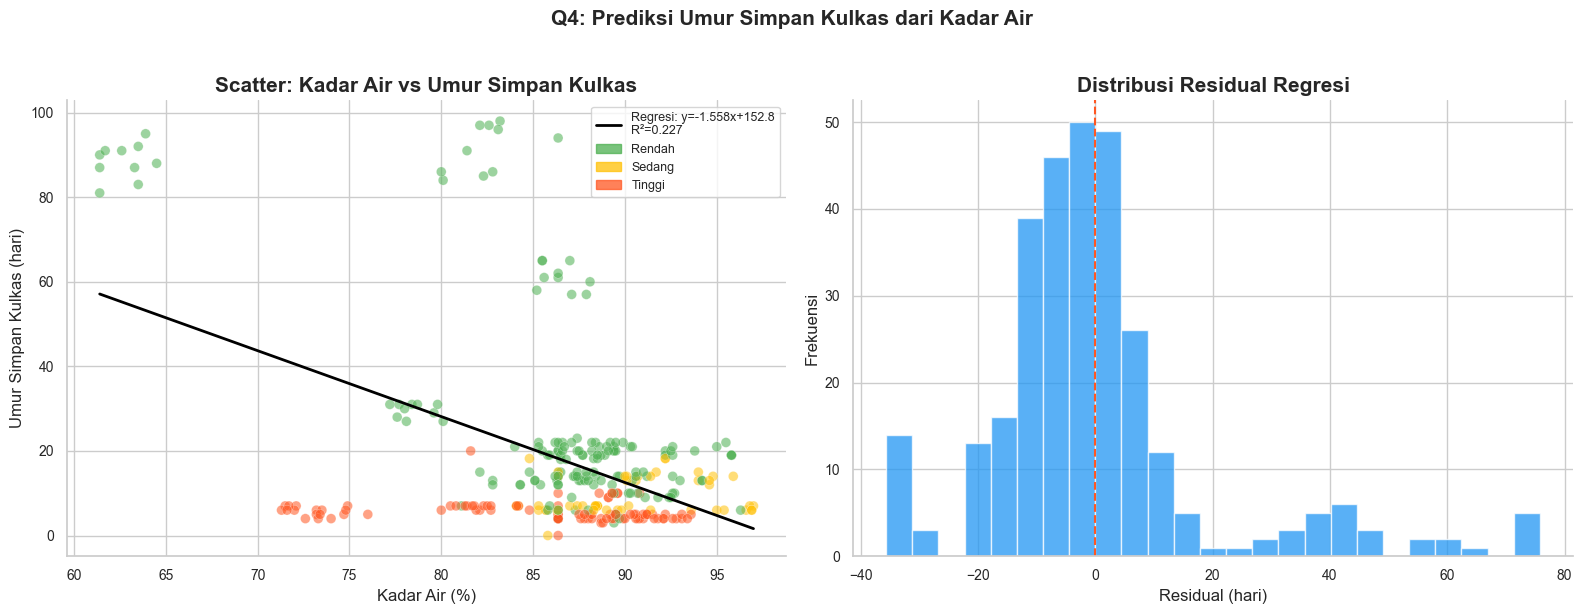

Insight:
Kadar air memiliki korelasi NEGATIF (r=-0.48) dengan umur simpan kulkas.
Semakin tinggi kadar air → semakin PENDEK umur simpan. Namun R² hanya
22.7% — kadar air bukan satu-satunya faktor penentu. Model multi-variabel
(termasuk laju respirasi & kategori produk) akan memberikan prediksi lebih akurat.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter + Regression Line
ax = axes[0]
resp_colors = df['respiration_rate'].map({'rendah': COLOR_OK, 'sedang': '#FFC107', 'tinggi': COLOR_WARN})
ax.scatter(x, y, c=resp_colors, alpha=0.55, s=50, edgecolors='white', linewidths=0.3)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', lw=2, label=f'Regresi: y={slope:.3f}x+{intercept:.1f}\nR²={r_val**2:.3f}')
ax.set_xlabel('Kadar Air (%)')
ax.set_ylabel('Umur Simpan Kulkas (hari)')
ax.set_title('Scatter: Kadar Air vs Umur Simpan Kulkas', fontweight='bold')
ax.legend(fontsize=9)
patches = [mpatches.Patch(color=c, label=r.capitalize(), alpha=0.75)
           for r, c in {'rendah': COLOR_OK, 'sedang': '#FFC107', 'tinggi': COLOR_WARN}.items()]
ax.legend(handles=[ax.lines[0]] + patches, fontsize=9)

# Distribusi residual
y_pred = slope * x + intercept
residuals = y - y_pred
axes[1].hist(residuals, bins=25, color=COLOR_ACCENT, alpha=0.75, edgecolor='white')
axes[1].axvline(0, color=COLOR_WARN, linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (hari)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual Regresi', fontweight='bold')

plt.suptitle('Q4: Prediksi Umur Simpan Kulkas dari Kadar Air', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
print(f"Kadar air memiliki korelasi NEGATIF (r={r_pearson:.2f}) dengan umur simpan kulkas.")
print("Semakin tinggi kadar air → semakin PENDEK umur simpan. Namun R² hanya")
print(f"{r_val**2*100:.1f}% — kadar air bukan satu-satunya faktor penentu. Model multi-variabel")
print("(termasuk laju respirasi & kategori produk) akan memberikan prediksi lebih akurat.")

## Q5: Apakah Produk Sensitif Dingin Memiliki Kadar Air Lebih Rendah?

In [50]:
chilling_groups = {
    True:  df[df['sensitivity_to_chilling'] == True]['water_content_pct'],
    False: df[df['sensitivity_to_chilling'] == False]['water_content_pct'],
}

# Statistik deskriptif
q5_desc = df.groupby('sensitivity_to_chilling')['water_content_pct'].describe().round(2)
print("=== Statistik Kadar Air per Sensitivitas Dingin ===")
print(q5_desc.to_string())

# Uji Statistik: Mann-Whitney U (non-parametric)
u_stat, p_mw = stats.mannwhitneyu(chilling_groups[True], chilling_groups[False], alternative='two-sided')
t_stat, p_tt = stats.ttest_ind(chilling_groups[True], chilling_groups[False])
print(f"\nMann-Whitney U : U={u_stat:.1f}, p={p_mw:.4f}")
print(f"T-test         : t={t_stat:.3f}, p={p_tt:.4f}")
print(f"Kesimpulan     : {'Perbedaan signifikan' if p_mw < 0.05 else 'Perbedaan tidak signifikan'}")

=== Statistik Kadar Air per Sensitivitas Dingin ===
                         count   mean   std   min    25%   50%   75%   max
sensitivity_to_chilling                                                   
False                    231.0  86.97  6.84  61.4  85.35  88.2  90.8  97.0
True                      73.0  84.45  6.10  71.5  82.30  87.3  88.4  91.4

Mann-Whitney U : U=6213.5, p=0.0007
T-test         : t=-2.806, p=0.0053
Kesimpulan     : Perbedaan signifikan


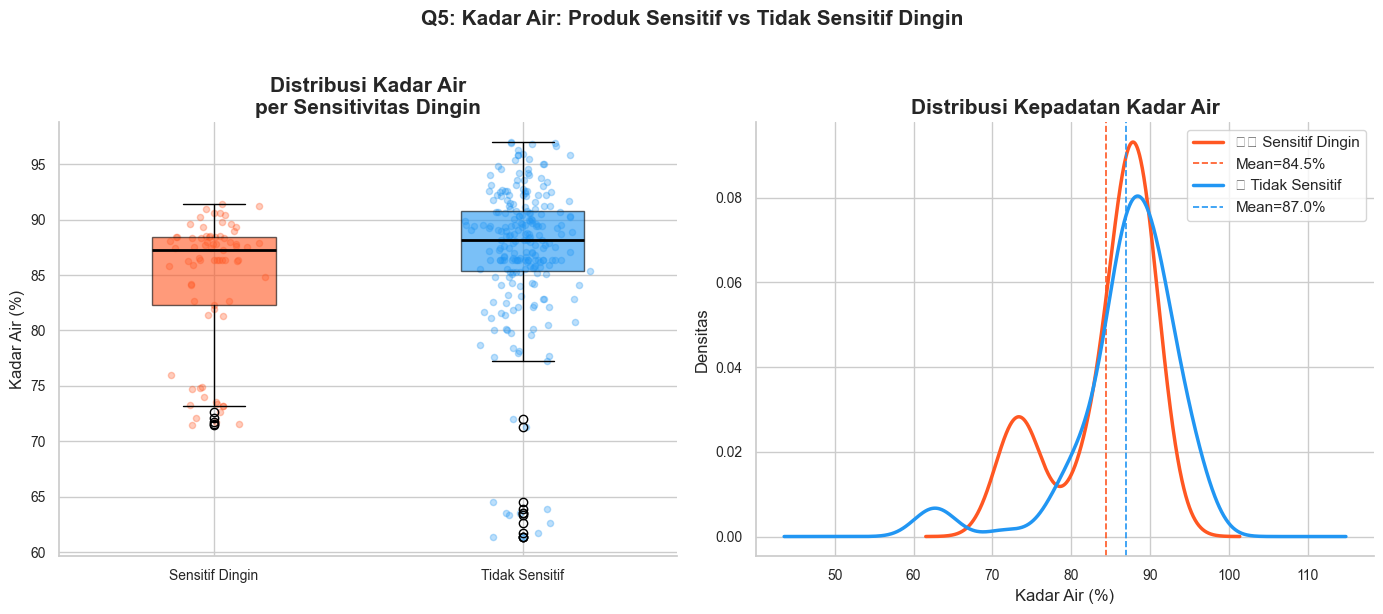

Insight:
Mean kadar air sensitif dingin : 84.45%
Mean kadar air tidak sensitif  : 86.97%
Produk sensitif dingin memiliki kadar air LEBIH RENDAH (-2.51%)


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_chill = {True: COLOR_WARN, False: COLOR_ACCENT}
labels_chill = {True: '⚠️ Sensitif Dingin', False: '✅ Tidak Sensitif'}

# Boxplot + Stripplot
ax = axes[0]
for i, (val, grp) in enumerate(chilling_groups.items()):
    ax.boxplot(grp, positions=[i], patch_artist=True,
               boxprops=dict(facecolor=colors_chill[val], alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               widths=0.4)
    ax.scatter(np.random.normal(i, 0.07, len(grp)), grp,
               alpha=0.3, s=20, color=colors_chill[val])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sensitif Dingin', 'Tidak Sensitif'])
ax.set_ylabel('Kadar Air (%)')
ax.set_title('Distribusi Kadar Air\nper Sensitivitas Dingin', fontweight='bold')

# KDE Plot
ax2 = axes[1]
for val, grp in chilling_groups.items():
    grp.plot.kde(ax=ax2, color=colors_chill[val],
                 linewidth=2.5, label=labels_chill[val])
    ax2.axvline(grp.mean(), color=colors_chill[val], linestyle='--', lw=1.2,
                label=f'Mean={grp.mean():.1f}%')
ax2.set_xlabel('Kadar Air (%)')
ax2.set_ylabel('Densitas')
ax2.set_title('Distribusi Kepadatan Kadar Air', fontweight='bold')
ax2.legend()

plt.suptitle('Q5: Kadar Air: Produk Sensitif vs Tidak Sensitif Dingin',
             fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

mean_sens   = chilling_groups[True].mean()
mean_nosens = chilling_groups[False].mean()
print(f"Insight:")
print(f"Mean kadar air sensitif dingin : {mean_sens:.2f}%")
print(f"Mean kadar air tidak sensitif  : {mean_nosens:.2f}%")
diff = mean_sens - mean_nosens
direction = "LEBIH RENDAH" if diff < 0 else "LEBIH TINGGI"
print(f"Produk sensitif dingin memiliki kadar air {direction} ({diff:+.2f}%)")

## Q6: Distribusi Umur Simpan Suhu Ruang untuk Produk "High Respiration"

In [52]:
high_resp = df[df['respiration_rate'] == 'tinggi']['standard_shelf_life_room']
all_other = df[df['respiration_rate'] != 'tinggi']['standard_shelf_life_room']

print(f"Produk Respirasi Tinggi  : {len(high_resp)} item")
print(f"Statistik deskriptif:")
print(high_resp.describe().round(2).to_string())

# Uji normalitas
stat_norm, p_norm = stats.shapiro(high_resp)
print(f"\nUji Shapiro-Wilk: W={stat_norm:.3f}, p={p_norm:.4f}")
print(f"Distribusi: {'Normal ✅' if p_norm > 0.05 else 'Tidak Normal'}")

Produk Respirasi Tinggi  : 95 item
Statistik deskriptif:
count    95.00
mean      1.82
std       1.20
min       0.00
25%       1.00
50%       2.00
75%       2.00
max       6.91

Uji Shapiro-Wilk: W=0.892, p=0.0000
Distribusi: Tidak Normal


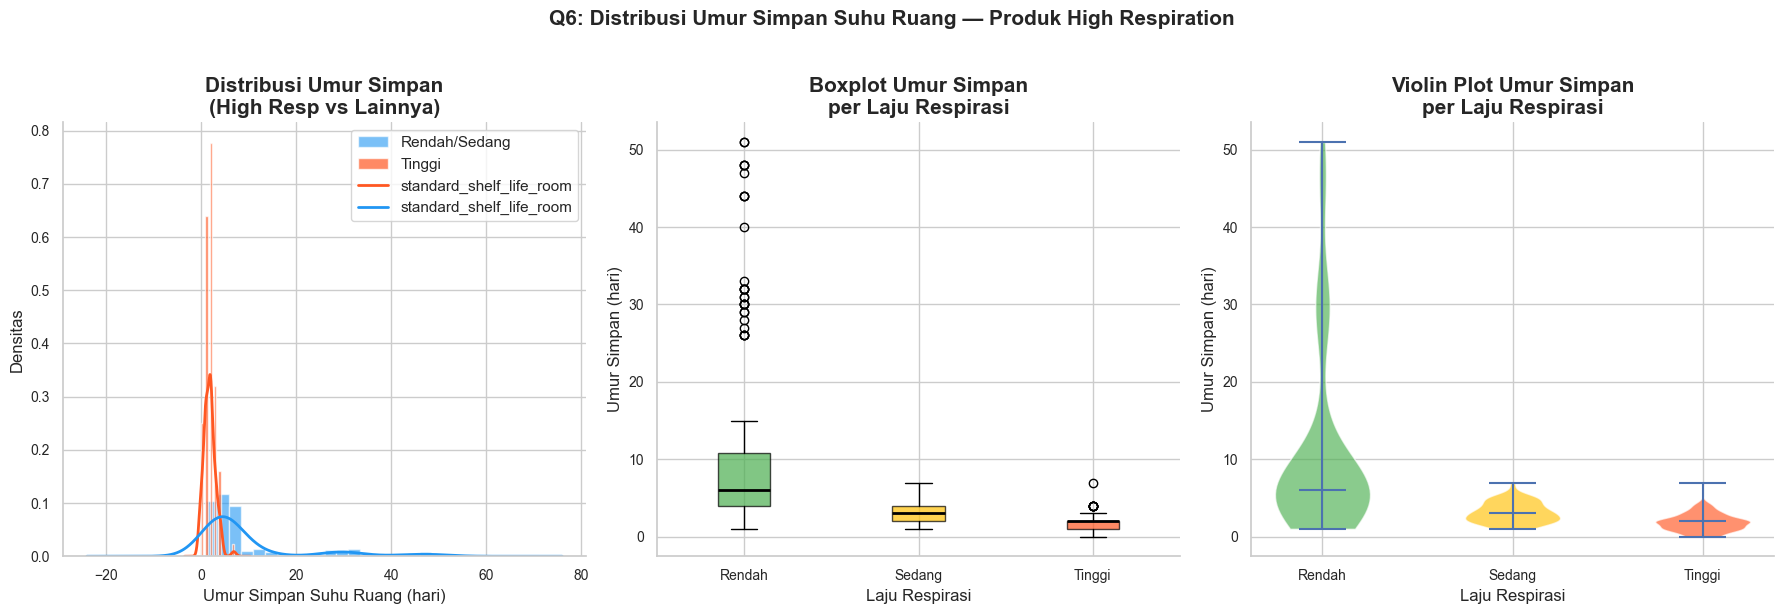

Insight:
Median umur simpan produk respirasi tinggi : 2.0 hari
Median umur simpan produk lainnya          : 5.0 hari
Produk High Respiration cenderung lebih cepat rusak & butuh rotasi inventaris lebih sering.


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram + KDE: High Resp vs Others
axes[0].hist(all_other, bins=20, alpha=0.6, color=COLOR_ACCENT, label='Rendah/Sedang', density=True)
axes[0].hist(high_resp,  bins=15, alpha=0.7, color=COLOR_WARN,   label='Tinggi',        density=True)
high_resp.plot.kde(ax=axes[0], color=COLOR_WARN,   lw=2)
all_other.plot.kde(ax=axes[0], color=COLOR_ACCENT, lw=2)
axes[0].set_xlabel('Umur Simpan Suhu Ruang (hari)')
axes[0].set_ylabel('Densitas')
axes[0].set_title('Distribusi Umur Simpan\n(High Resp vs Lainnya)', fontweight='bold')
axes[0].legend()

# Boxplot per kategori respirasi
rate_data = [df[df['respiration_rate'] == r]['standard_shelf_life_room'].dropna()
             for r in ['rendah', 'sedang', 'tinggi']]
colors_box = [COLOR_OK, '#FFC107', COLOR_WARN]
bp = axes[1].boxplot(rate_data, patch_artist=True, notch=False,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_xticklabels(['Rendah', 'Sedang', 'Tinggi'])
axes[1].set_xlabel('Laju Respirasi')
axes[1].set_ylabel('Umur Simpan (hari)')
axes[1].set_title('Boxplot Umur Simpan\nper Laju Respirasi', fontweight='bold')

# Violin plot
parts = axes[2].violinplot(rate_data, positions=[1, 2, 3], showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], colors_box):
    pc.set_facecolor(c); pc.set_alpha(0.65)
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(['Rendah', 'Sedang', 'Tinggi'])
axes[2].set_xlabel('Laju Respirasi')
axes[2].set_ylabel('Umur Simpan (hari)')
axes[2].set_title('Violin Plot Umur Simpan\nper Laju Respirasi', fontweight='bold')

plt.suptitle('Q6: Distribusi Umur Simpan Suhu Ruang — Produk High Respiration',
             fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Insight:")
print(f"Median umur simpan produk respirasi tinggi : {high_resp.median():.1f} hari")
print(f"Median umur simpan produk lainnya          : {all_other.median():.1f} hari")
print(f"Produk High Respiration cenderung lebih cepat rusak & butuh rotasi inventaris lebih sering.")

## Q7: Produk dengan Risiko Food Waste Tertinggi (Umur Simpan < 3 Hari)

In [29]:
high_waste = df[df['standard_shelf_life_room'] < 3].copy()

waste_by_product = (
    high_waste.groupby('item_name', observed=True)
    .agg(
        item_type         =('item_type',                 'first'),
        avg_room          =('standard_shelf_life_room',  'mean'),
        avg_fridge        =('standard_shelf_life_fridge','mean'),
        avg_water_pct     =('water_content_pct',         'mean'),
        pct_high_resp     =('respiration_rate',           lambda x: (x=='tinggi').mean()*100),
        n                 =('item_name',                 'count'),
    )
    .reset_index()
    .sort_values('avg_room')
)

print(f"Produk berisiko tinggi (umur <3 hari) : {len(waste_by_product)} jenis produk")
print()
waste_by_product.round(2)

Produk berisiko tinggi (umur <3 hari) : 18 jenis produk



,item_name,item_type,avg_room,avg_fridge,avg_water_pct,pct_high_resp,n
0,Bayam,Unknown,0.00,5.00,90.60,100.00,1
1,Kangkung,Leafy Vegetable,0.00,4.00,89.00,100.00,1
6,Bayam,Leafy Vegetable,0.56,4.33,92.14,100.00,9
9,Kangkung,Unknown,0.62,3.25,88.55,87.50,8
14,Sawi Hijau,Leafy Vegetable,0.78,4.67,90.38,100.00,9
3,Sawi Hijau,Leafy Vegetable,1.00,5.00,90.50,100.00,1
15,Selada,Leafy Vegetable,1.40,6.20,95.09,0.00,10
12,Pepaya,Tropical Fruit,1.44,4.44,87.65,100.00,9
13,Pisang,Tropical Fruit,1.56,4.44,78.11,100.00,9
17,Stroberi,Berry,1.73,4.45,90.30,81.82,11


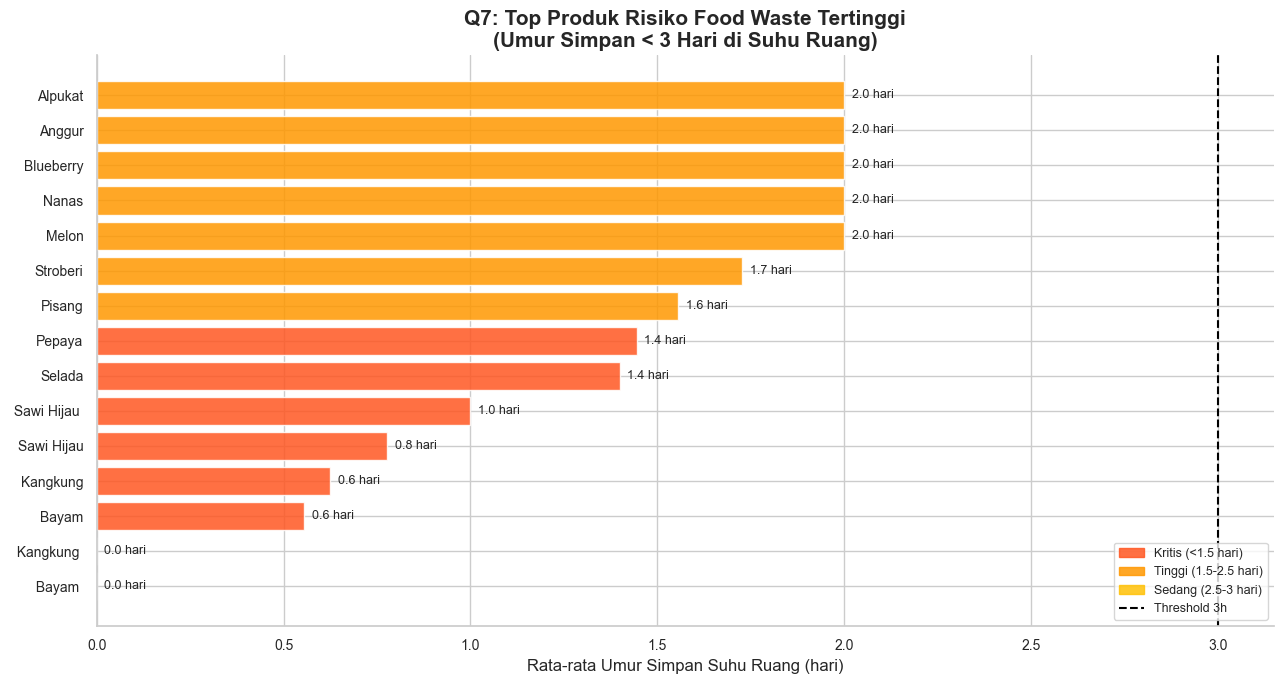

Rekomendasi:
Terapkan sistem FIFO ketat untuk produk ini
Pertimbangkan pembelian dalam batch kecil / just-in-time procurement
Aktifkan alert otomatis jika stok mendekati batas umur simpan


In [56]:
top_waste = waste_by_product.head(15).sort_values('avg_room', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
colors = [COLOR_WARN if r < 1.5 else '#FF9800' if r < 2.5 else '#FFC107'
          for r in top_waste['avg_room']]
bars = ax.barh(top_waste['item_name'], top_waste['avg_room'], color=colors, alpha=0.85, edgecolor='white')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
            f'{w:.1f} hari', va='center', fontsize=9)

ax.axvline(3, color='black', linestyle='--', lw=1.5, label='Threshold 3 hari')
ax.set_xlabel('Rata-rata Umur Simpan Suhu Ruang (hari)')
ax.set_title('Q7: Top Produk Risiko Food Waste Tertinggi\n(Umur Simpan < 3 Hari di Suhu Ruang)',
             fontweight='bold')
ax.legend()

# Color legend
patches_w = [
    mpatches.Patch(color=COLOR_WARN, label='Kritis (<1.5 hari)', alpha=0.85),
    mpatches.Patch(color='#FF9800',  label='Tinggi (1.5-2.5 hari)', alpha=0.85),
    mpatches.Patch(color='#FFC107',  label='Sedang (2.5-3 hari)', alpha=0.85),
]
ax.legend(handles=patches_w + [plt.Line2D([0],[0], color='black', lw=1.5, linestyle='--', label='Threshold 3h')],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("Rekomendasi:")
print("Terapkan sistem FIFO ketat untuk produk ini")
print("Pertimbangkan pembelian dalam batch kecil / just-in-time procurement")
print("Aktifkan alert otomatis jika stok mendekati batas umur simpan")

### Q8: Kerugian Umur Simpan Produk Sensitif Dingin yang Dimasukkan Kulkas

In [31]:
cold_loss = df[df['sensitivity_to_chilling'] == True].copy()
cold_loss['shelf_life_loss'] = cold_loss['standard_shelf_life_room'] - cold_loss['standard_shelf_life_fridge']
cold_loss['loss_pct'] = (cold_loss['shelf_life_loss'] / cold_loss['standard_shelf_life_room'] * 100).clip(lower=0)

loss_summary = (
    cold_loss.groupby('item_name', observed=True)
    .agg(
        avg_room   =('standard_shelf_life_room',   'mean'),
        avg_fridge =('standard_shelf_life_fridge', 'mean'),
        avg_loss   =('shelf_life_loss',            'mean'),
        avg_loss_pct=('loss_pct',                  'mean'),
    )
    .reset_index()
    .sort_values('avg_loss_pct', ascending=False)
)

print("=== Estimasi Kerugian Umur Simpan Produk Sensitif Dingin ===")
loss_summary.round(2)

=== Estimasi Kerugian Umur Simpan Produk Sensitif Dingin ===


,item_name,avg_room,avg_fridge,avg_loss,avg_loss_pct
0,Nanas,3.00,6.00,-3.00,0.0
1,Pisang,2.00,4.00,-2.00,0.0
2,Alpukat,2.12,6.50,-4.38,0.0
3,Cabai Hijau,4.60,13.80,-9.20,0.0
4,Cabai Merah,4.57,13.86,-9.29,0.0
5,Mangga,3.70,6.70,-3.00,0.0
6,Melon,2.99,6.60,-3.61,0.0
7,Nanas,2.50,6.50,-4.00,0.0
8,Pepaya,1.44,4.44,-3.00,0.0
9,Pisang,1.56,4.44,-2.89,0.0


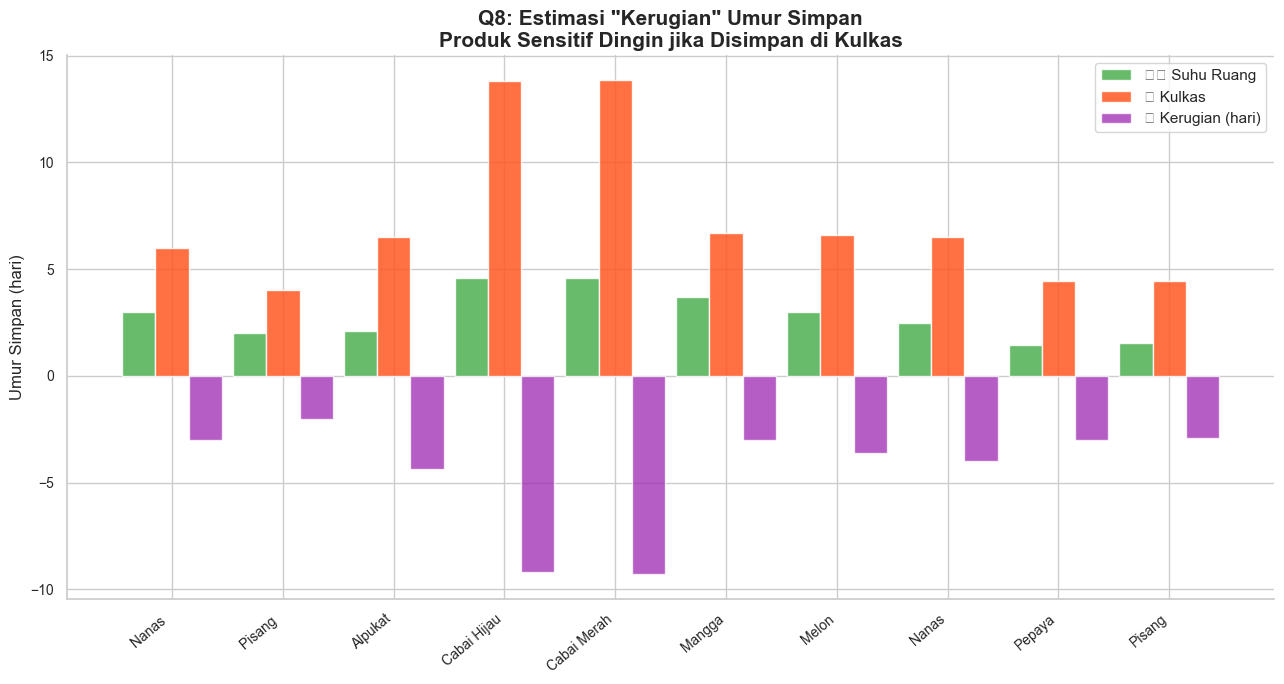

Insight:
Produk dengan kerugian umur simpan tertinggi:  Nanas 
Kehilangan estimasi : -3.0 hari (0% dari umur normal)
Rekomendasi: JANGAN simpan produk ini di kulkas — gunakan area penyimpanan bersuhu ruang.


In [57]:
fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(loss_summary))
w = 0.3
ax.bar(x - w,   loss_summary['avg_room'],   w, label='🌡️ Suhu Ruang',  color=COLOR_OK,   alpha=0.85)
ax.bar(x,       loss_summary['avg_fridge'], w, label='🧊 Kulkas',       color=COLOR_WARN, alpha=0.85)
ax.bar(x + w,   loss_summary['avg_loss'],   w, label='📉 Kerugian (hari)', color='#9C27B0', alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels(loss_summary['item_name'], rotation=40, ha='right')
ax.set_ylabel('Umur Simpan (hari)')
ax.set_title('Q8: Estimasi "Kerugian" Umur Simpan\nProduk Sensitif Dingin jika Disimpan di Kulkas',
             fontweight='bold')
ax.legend()

for i, (_, row) in enumerate(loss_summary.iterrows()):
    if row['avg_loss_pct'] > 0:
        ax.text(i + w, row['avg_loss'] + 0.1, f"-{row['avg_loss_pct']:.0f}%",
                ha='center', va='bottom', fontsize=8, color='#9C27B0', fontweight='bold')

plt.tight_layout()
plt.show()

worst = loss_summary.iloc[0]
print(f"Insight:")
print(f"Produk dengan kerugian umur simpan tertinggi: {worst['item_name']}")
print(f"Kehilangan estimasi : {worst['avg_loss']:.1f} hari ({worst['avg_loss_pct']:.0f}% dari umur normal)")
print(f"Rekomendasi: JANGAN simpan produk ini di kulkas — gunakan area penyimpanan bersuhu ruang.")

## Q9: Kategori Produk yang Paling Cocok untuk Sistem FIFO

In [33]:
fifo_analysis = df.groupby('item_type', observed=True).agg(
    avg_room_shelf  =('standard_shelf_life_room',  'mean'),
    std_room_shelf  =('standard_shelf_life_room',  'std'),
    avg_fridge_shelf=('standard_shelf_life_fridge','mean'),
    pct_waste_risk  =('standard_shelf_life_room',   lambda x: (x < 3).mean() * 100),
    pct_chilling    =('sensitivity_to_chilling',    'mean'),
    pct_high_resp   =('respiration_rate',            lambda x: (x=='tinggi').mean() * 100),
    n               =('item_name',                  'count')
).reset_index()

# FIFO Score: semakin tinggi score = semakin urgent FIFO
fifo_analysis['fifo_urgency_score'] = (
    (1 / (fifo_analysis['avg_room_shelf'] + 0.5)) * 50 +
    (fifo_analysis['pct_waste_risk'] / 100) * 30 +
    (fifo_analysis['pct_high_resp'] / 100) * 20
).round(2)

fifo_analysis = fifo_analysis.sort_values('fifo_urgency_score', ascending=False)
print("=== Skor Urgensi FIFO per Kategori (Skala 0-100) ===")
fifo_analysis[['item_type','avg_room_shelf','pct_waste_risk','fifo_urgency_score']].round(2)

=== Skor Urgensi FIFO per Kategori (Skala 0-100) ===


,item_type,avg_room_shelf,pct_waste_risk,fifo_urgency_score
0,Berry,1.95,89.47,56.75
3,Leafy Vegetable,1.92,74.07,54.70
6,Tropical Fruit,2.68,52.56,41.50
5,Temperate Fruit,4.40,14.81,21.31
7,Unknown,9.00,29.17,19.02
1,Chili,4.50,0.00,10.00
2,Citrus Fruit,5.68,0.00,8.09
4,Root Vegetable,21.28,0.00,2.30


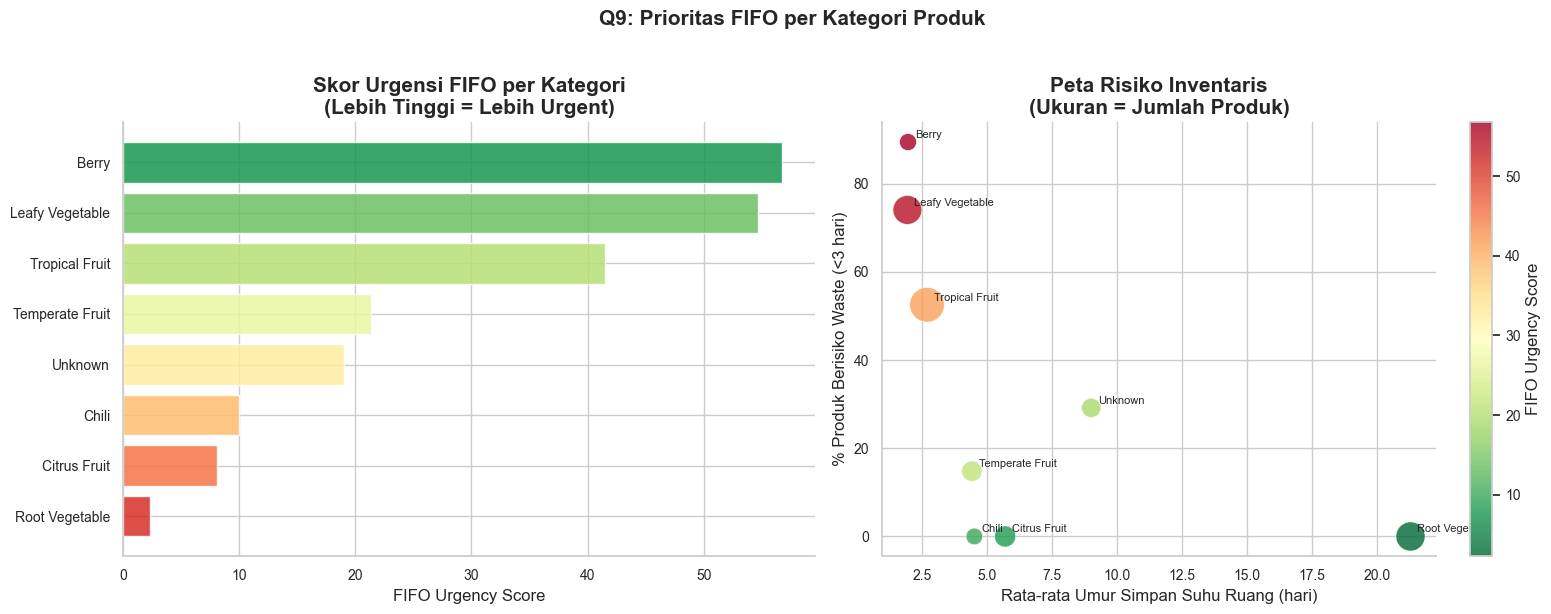

Rekomendasi FIFO:
Kategori prioritas FIFO TERTINGGI : Berry, Leafy Vegetable, Tropical Fruit
Produk ini harus selalu dirotasi paling pertama & dibeli dalam kuantitas lebih kecil.


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FIFO Urgency Score
norm_scores = fifo_analysis['fifo_urgency_score']
colors_fifo = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fifo_analysis)))
axes[0].barh(fifo_analysis['item_type'][::-1], norm_scores[::-1],
             color=colors_fifo[::-1], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('FIFO Urgency Score')
axes[0].set_title('Skor Urgensi FIFO per Kategori\n(Lebih Tinggi = Lebih Urgent)', fontweight='bold')

# Scatter: Avg Shelf Life vs Waste Risk %
sc = axes[1].scatter(
    fifo_analysis['avg_room_shelf'],
    fifo_analysis['pct_waste_risk'],
    s=fifo_analysis['n'] * 8,
    c=fifo_analysis['fifo_urgency_score'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='white', linewidths=0.5
)
for _, row in fifo_analysis.iterrows():
    axes[1].annotate(row['item_type'],
                     (row['avg_room_shelf'], row['pct_waste_risk']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(sc, ax=axes[1], label='FIFO Urgency Score')
axes[1].set_xlabel('Rata-rata Umur Simpan Suhu Ruang (hari)')
axes[1].set_ylabel('% Produk Berisiko Waste (<3 hari)')
axes[1].set_title('Peta Risiko Inventaris\n(Ukuran = Jumlah Produk)', fontweight='bold')

plt.suptitle('Q9: Prioritas FIFO per Kategori Produk', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("Rekomendasi FIFO:")
top3_fifo = fifo_analysis.head(3)['item_type'].tolist()
print(f"Kategori prioritas FIFO TERTINGGI : {', '.join(top3_fifo)}")
print("Produk ini harus selalu dirotasi paling pertama & dibeli dalam kuantitas lebih kecil.")

### Q10 · Apakah Penghasil Etilen Memiliki Umur Simpan Lebih Pendek?

In [35]:
ethylene_groups = {
    True:  df[df['ethylene_producer'] == True],
    False: df[df['ethylene_producer'] == False],
}

eth_stats = df.groupby('ethylene_producer').agg(
    n              =('item_name',                  'count'),
    avg_room       =('standard_shelf_life_room',   'mean'),
    med_room       =('standard_shelf_life_room',   'median'),
    avg_fridge     =('standard_shelf_life_fridge', 'mean'),
    avg_water_pct  =('water_content_pct',          'mean'),
    pct_high_resp  =('respiration_rate',            lambda x: (x=='tinggi').mean()*100),
).round(2)

print("=== Perbandingan Penghasil Etilen vs Non-Etilen ===")
eth_stats

=== Perbandingan Penghasil Etilen vs Non-Etilen ===


,n,avg_room,med_room,avg_fridge,avg_water_pct,pct_high_resp
ethylene_producer,,,,,,
False,199,8.75,4.0,22.60,87.08,19.10
True,105,3.43,3.0,9.88,85.00,54.29


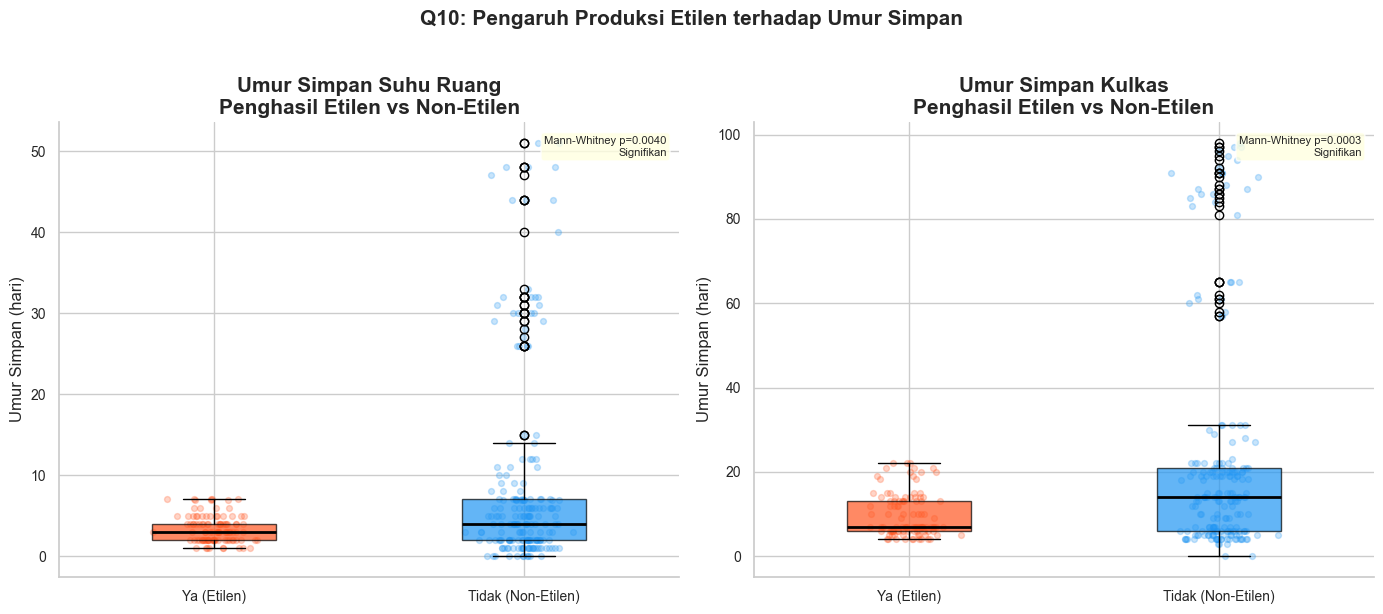

Insight:
Mean umur simpan penghasil etilen     : 3.43 hari
Mean umur simpan non-penghasil etilen : 8.75 hari
Pisahkan produk penghasil etilen dari yang sensitif etilen dalam penyimpanan!


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_eth = {True: COLOR_WARN, False: COLOR_ACCENT}
labels_eth = {True: 'Penghasil Etilen', False: 'Bukan Penghasil Etilen'}

for metric, ax, title in [
    ('standard_shelf_life_room',   axes[0], 'Umur Simpan Suhu Ruang'),
    ('standard_shelf_life_fridge', axes[1], 'Umur Simpan Kulkas'),
]:
    grp_data = [df[df['ethylene_producer'] == v][metric].dropna() for v in [True, False]]
    bp = ax.boxplot(grp_data, patch_artist=True,
                    medianprops={'color':'black','linewidth':2}, widths=0.4)
    for patch, v in zip(bp['boxes'], [True, False]):
        patch.set_facecolor(colors_eth[v]); patch.set_alpha(0.7)
    for i, grp in enumerate(grp_data):
        ax.scatter(np.random.normal(i+1, 0.06, len(grp)), grp,
                   alpha=0.25, s=18, color=list(colors_eth.values())[i])
    ax.set_xticklabels(['Ya (Etilen)', 'Tidak (Non-Etilen)'])
    ax.set_ylabel('Umur Simpan (hari)')
    ax.set_title(f'{title}\nPenghasil Etilen vs Non-Etilen', fontweight='bold')

    u_stat, p_mw = stats.mannwhitneyu(grp_data[0], grp_data[1], alternative='two-sided')
    sig = "Signifikan" if p_mw < 0.05 else "❌ Tidak Signifikan"
    ax.text(0.98, 0.97, f'Mann-Whitney p={p_mw:.4f}\n{sig}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Q10: Pengaruh Produksi Etilen terhadap Umur Simpan', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
mean_eth     = ethylene_groups[True]['standard_shelf_life_room'].mean()
mean_noneth  = ethylene_groups[False]['standard_shelf_life_room'].mean()
print(f"Mean umur simpan penghasil etilen     : {mean_eth:.2f} hari")
print(f"Mean umur simpan non-penghasil etilen : {mean_noneth:.2f} hari")
print("Pisahkan produk penghasil etilen dari yang sensitif etilen dalam penyimpanan!")

### Q11 · Peta Risiko Produk: Kadar Air vs Laju Respirasi

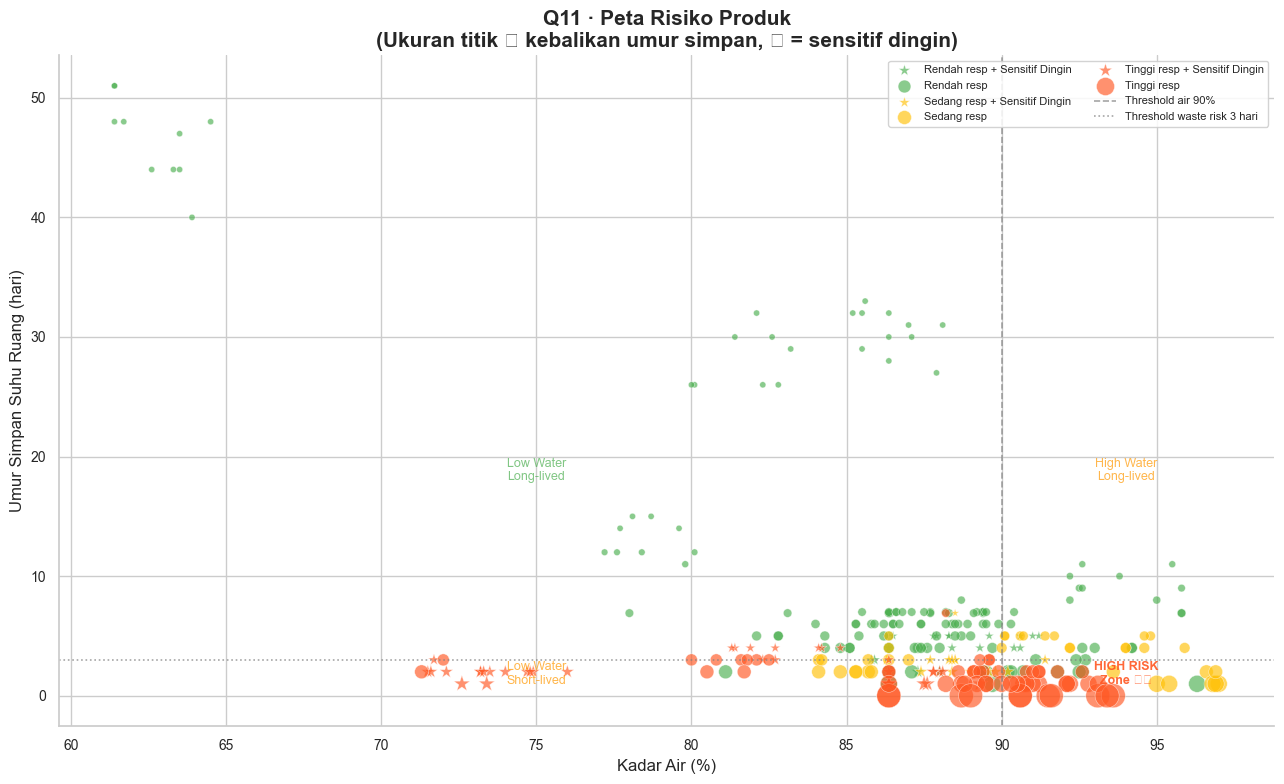

Insight:
Produk di kuadran KANAN-BAWAH (kadar air >90%, umur simpan <3 hari) adalah zona risiko tertinggi.
Identifikasi produk di zona ini dan prioritaskan dalam strategi pengadaan & display.


In [62]:
fig, ax = plt.subplots(figsize=(13, 8))

resp_map   = {'rendah': 1, 'sedang': 2, 'tinggi': 3}
colors_r   = {'rendah': COLOR_OK, 'sedang': '#FFC107', 'tinggi': COLOR_WARN}
markers_c  = {True: '*', False: 'o'}
sizes      = df['standard_shelf_life_room'].apply(lambda x: max(20, 300 / (x + 1)))

for resp_rate in ['rendah', 'sedang', 'tinggi']:
    for sens in [True, False]:
        subset = df[(df['respiration_rate'] == resp_rate) & (df['sensitivity_to_chilling'] == sens)]
        if len(subset) == 0:
            continue
        label = f"{resp_rate.capitalize()} resp" + (" + Sensitif Dingin" if sens else "")
        ax.scatter(
            subset['water_content_pct'],
            subset['standard_shelf_life_room'],
            c=colors_r[resp_rate],
            marker=markers_c[sens],
            s=sizes[subset.index],
            alpha=0.65,
            edgecolors='white',
            linewidths=0.4,
            label=label
        )

# Quadrant lines
ax.axvline(90, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Threshold air 90%')
ax.axhline(3,  color='gray', linestyle=':',  lw=1.2, alpha=0.7, label='Threshold waste risk 3 hari')

# Quadrant labels
ax.text(75, 18, 'Low Water\nLong-lived', ha='center', fontsize=9, color='#4CAF50', alpha=0.7)
ax.text(94, 18, 'High Water\nLong-lived', ha='center', fontsize=9, color='#FF9800', alpha=0.7)
ax.text(75, 1,  'Low Water\nShort-lived', ha='center', fontsize=9, color='#FF9800', alpha=0.7)
ax.text(94, 1,  'HIGH RISK\nZone ⚠️', ha='center', fontsize=9, color=COLOR_WARN, alpha=0.9, fontweight='bold')

ax.set_xlabel('Kadar Air (%)', fontsize=12)
ax.set_ylabel('Umur Simpan Suhu Ruang (hari)', fontsize=12)
ax.set_title('Q11 · Peta Risiko Produk\n(Ukuran titik ∝ kebalikan umur simpan, ★ = sensitif dingin)',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()

print("Insight:")
print("Produk di kuadran KANAN-BAWAH (kadar air >90%, umur simpan <3 hari) adalah zona risiko tertinggi.")
print("Identifikasi produk di zona ini dan prioritaskan dalam strategi pengadaan & display.")

### Q12: Produk Stabil untuk Stok Buffer Jangka Panjang

In [38]:
# Kriteria stok buffer: shelf_life_room > 7, shelf_life_fridge > 14,
# bukan sensitif dingin, respirasi rendah/sedang, kadar air rendah
buffer_candidates = df[
    (df['standard_shelf_life_room']   > 7) &
    (df['standard_shelf_life_fridge'] > 14) &
    (df['sensitivity_to_chilling']    == False) &
    (df['respiration_rate'].isin(['rendah', 'sedang']))
].copy()

buffer_summary = (
    buffer_candidates.groupby('item_name', observed=True)
    .agg(
        item_type         =('item_type',                 'first'),
        avg_room          =('standard_shelf_life_room',  'mean'),
        avg_fridge        =('standard_shelf_life_fridge','mean'),
        avg_water_pct     =('water_content_pct',         'mean'),
        respiration_rate  =('respiration_rate',           'first'),
        n                 =('item_name',                 'count'),
    )
    .reset_index()
    .sort_values('avg_fridge', ascending=False)
    .head(20)
)

print(f"Kandidat stok buffer jangka panjang: {len(buffer_summary)} produk")
buffer_summary.round(2)

Kandidat stok buffer jangka panjang: 10 produk


,item_name,item_type,avg_room,avg_fridge,avg_water_pct,respiration_rate,n
6,Jahe,Root Vegetable,28.38,91.50,82.61,rendah,8
0,Bawang Putih,Root Vegetable,51.00,90.00,61.40,rendah,1
5,Bawang Putih,Root Vegetable,46.00,88.33,62.87,rendah,9
1,Jahe,Unknown,26.00,86.00,80.00,rendah,1
4,Bawang Merah,Root Vegetable,30.70,61.10,86.46,rendah,10
7,Kentang,Root Vegetable,12.88,29.62,78.45,rendah,8
2,Kentang,Root Vegetable,14.00,29.00,79.60,rendah,1
3,Lobak,Root Vegetable,10.50,21.00,94.65,rendah,2
8,Lobak,Root Vegetable,9.14,19.86,93.27,rendah,7
9,Wortel,Root Vegetable,8.00,19.00,88.70,rendah,1


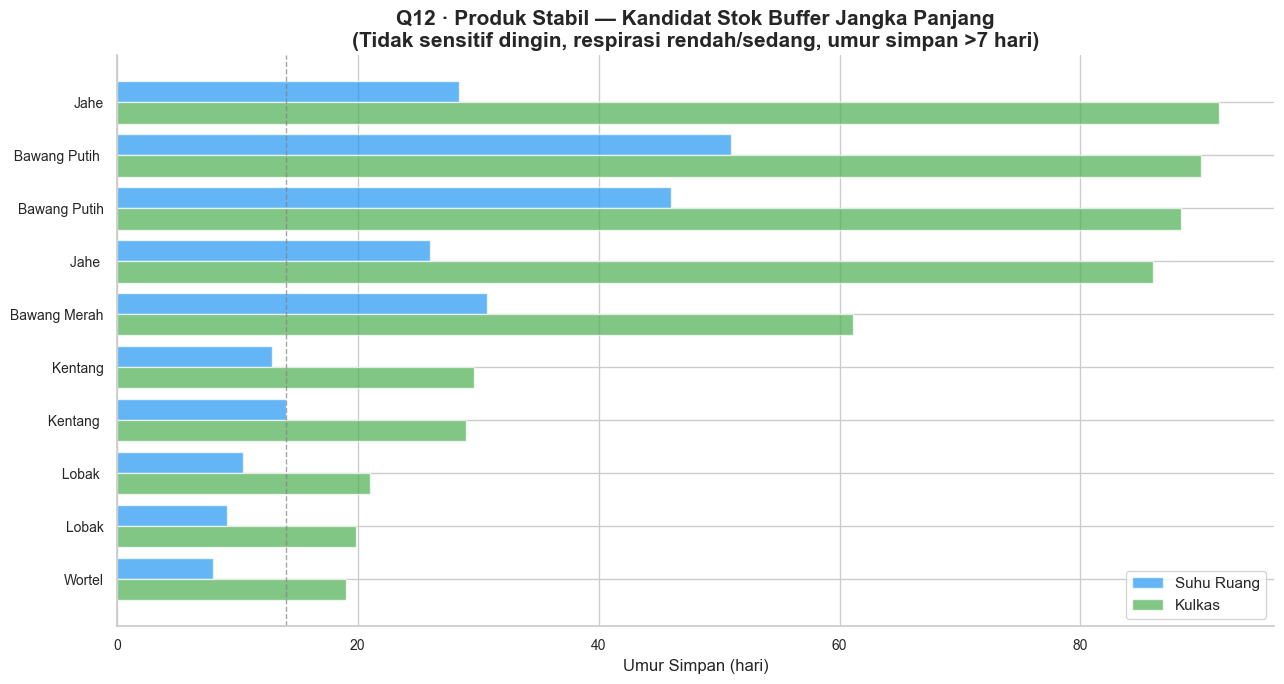


📌 Rekomendasi Stok Buffer:
  Top 5 produk paling stabil untuk buffer stok: Jahe,  Bawang Putih , Bawang Putih,  Jahe , Bawang Merah
  → Beli dalam kuantitas lebih besar, simpan di kulkas, rotasi setiap 2+ minggu.


In [39]:
fig, ax = plt.subplots(figsize=(13, 7))

top_buf = buffer_summary.head(15).sort_values('avg_fridge')
colors_buf = [COLOR_OK if r == 'rendah' else '#FFC107' for r in top_buf['respiration_rate']]

h_room   = ax.barh(top_buf['item_name'], top_buf['avg_room'],   0.4,
                   color=COLOR_ACCENT, alpha=0.7, label='Suhu Ruang', align='edge')
h_fridge = ax.barh(top_buf['item_name'], top_buf['avg_fridge'], -0.4,
                   color=COLOR_OK, alpha=0.7, label='Kulkas', align='edge')

ax.set_xlabel('Umur Simpan (hari)')
ax.set_title('Q12 · Produk Stabil — Kandidat Stok Buffer Jangka Panjang\n'
             '(Tidak sensitif dingin, respirasi rendah/sedang, umur simpan >7 hari)',
             fontweight='bold')
ax.legend()
ax.axvline(14, color='gray', linestyle='--', lw=1, alpha=0.7, label='14 hari (2 minggu)')

plt.tight_layout()
plt.show()

print("\n📌 Rekomendasi Stok Buffer:")
top5 = buffer_summary.head(5)['item_name'].tolist()
print(f"  Top 5 produk paling stabil untuk buffer stok: {', '.join(top5)}")
print("  → Beli dalam kuantitas lebih besar, simpan di kulkas, rotasi setiap 2+ minggu.")

---
## Dashboard Ringkasan – Semua Pertanyaan Bisnis

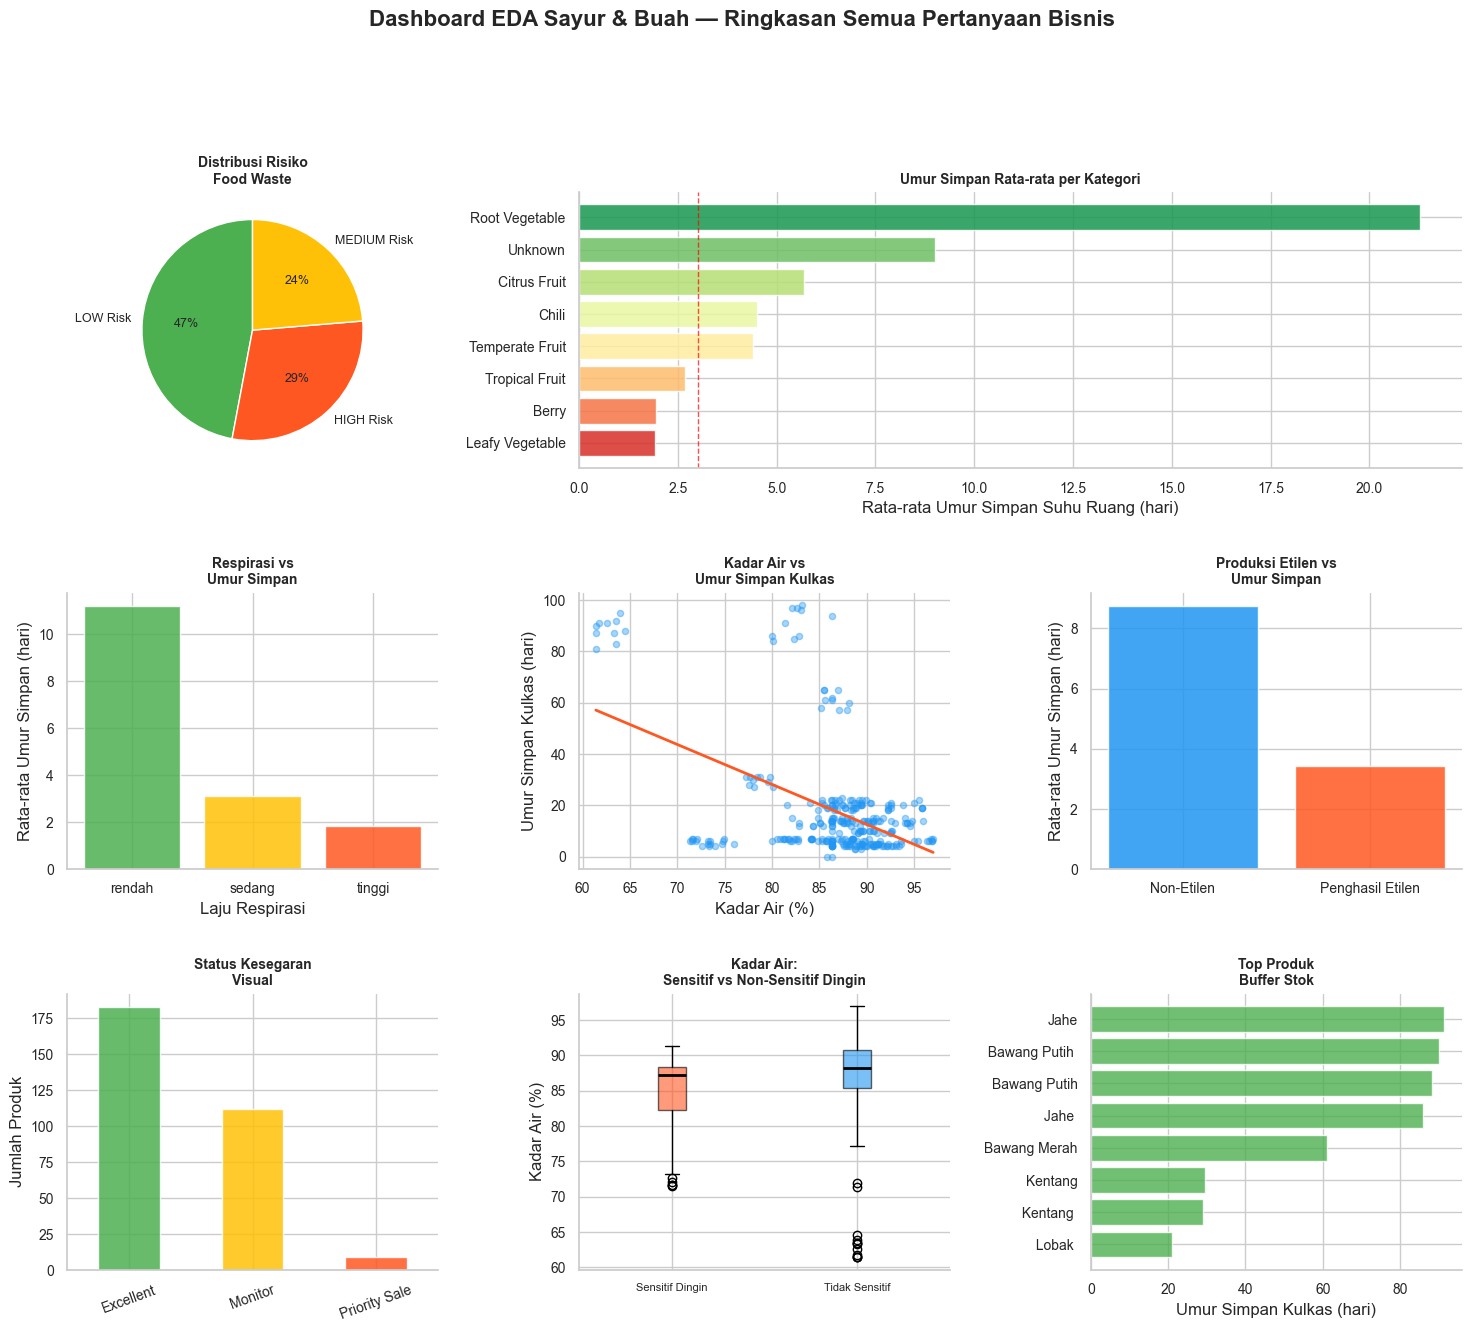

✅ Dashboard disimpan sebagai 'eda_dashboard_ringkasan.png'


In [61]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)

# Panel 1: Waste Risk Distribution 
ax1 = fig.add_subplot(gs[0, 0])
wrl = df['waste_risk_label'].value_counts()
colors_wr = {'HIGH Risk': COLOR_WARN, 'MEDIUM Risk': '#FFC107', 'LOW Risk': COLOR_OK}
wrl.plot.pie(ax=ax1, autopct='%1.0f%%', startangle=90,
             colors=[colors_wr.get(i, 'gray') for i in wrl.index],
             textprops={'fontsize': 9})
ax1.set_ylabel('')
ax1.set_title('Distribusi Risiko\nFood Waste', fontweight='bold', fontsize=10)

# Panel 2: Mean Shelf Life per Category 
ax2 = fig.add_subplot(gs[0, 1:])
cat_shelf = df.groupby('item_type', observed=True)['standard_shelf_life_room'].mean().sort_values()
bars2 = ax2.barh(cat_shelf.index, cat_shelf.values,
                 color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(cat_shelf))), alpha=0.85)
ax2.set_xlabel('Rata-rata Umur Simpan Suhu Ruang (hari)')
ax2.set_title('Umur Simpan Rata-rata per Kategori', fontweight='bold', fontsize=10)
ax2.axvline(3, color='red', linestyle='--', lw=1, alpha=0.7)

# Panel 3: Respirasi vs Shelf Life 
ax3 = fig.add_subplot(gs[1, 0])
resp_mean = df.groupby('respiration_rate', observed=True)['standard_shelf_life_room'].mean().reindex(['rendah','sedang','tinggi'])
ax3.bar(resp_mean.index, resp_mean.values,
        color=[COLOR_OK, '#FFC107', COLOR_WARN], alpha=0.85, edgecolor='white')
ax3.set_xlabel('Laju Respirasi')
ax3.set_ylabel('Rata-rata Umur Simpan (hari)')
ax3.set_title('Respirasi vs\nUmur Simpan', fontweight='bold', fontsize=10)

# Panel 4: Kadar Air vs Shelf Life (scatter) 
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(df['water_content_pct'], df['standard_shelf_life_fridge'],
            alpha=0.4, s=20, color=COLOR_ACCENT)
x4 = np.linspace(df['water_content_pct'].min(), df['water_content_pct'].max(), 100)
slope4, intercept4, *_ = stats.linregress(df['water_content_pct'], df['standard_shelf_life_fridge'])
ax4.plot(x4, slope4*x4+intercept4, color=COLOR_WARN, lw=2)
ax4.set_xlabel('Kadar Air (%)')
ax4.set_ylabel('Umur Simpan Kulkas (hari)')
ax4.set_title('Kadar Air vs\nUmur Simpan Kulkas', fontweight='bold', fontsize=10)

# Panel 5: Ethylene Producer vs Shelf Life 
ax5 = fig.add_subplot(gs[1, 2])
eth_room = df.groupby('ethylene_producer')['standard_shelf_life_room'].mean()
ax5.bar(['Non-Etilen', 'Penghasil Etilen'], [eth_room[False], eth_room[True]],
        color=[COLOR_ACCENT, COLOR_WARN], alpha=0.85, edgecolor='white')
ax5.set_ylabel('Rata-rata Umur Simpan (hari)')
ax5.set_title('Produksi Etilen vs\nUmur Simpan', fontweight='bold', fontsize=10)

# Panel 6: Freshness Status Distribution 
ax6 = fig.add_subplot(gs[2, 0])
fresh_counts = df['freshness_status'].value_counts()
colors_fresh = {'Priority Sale': COLOR_WARN, 'Monitor': '#FFC107', 'Excellent': COLOR_OK}
fresh_counts.plot.bar(ax=ax6,
                       color=[colors_fresh.get(k, 'gray') for k in fresh_counts.index],
                       edgecolor='white', alpha=0.85)
ax6.set_xlabel('')
ax6.set_ylabel('Jumlah Produk')
ax6.set_title('Status Kesegaran\nVisual', fontweight='bold', fontsize=10)
ax6.tick_params(axis='x', rotation=20)

# Panel 7: Sensitif Dingin vs Water Content 
ax7 = fig.add_subplot(gs[2, 1])
grp_t = df[df['sensitivity_to_chilling']==True]['water_content_pct']
grp_f = df[df['sensitivity_to_chilling']==False]['water_content_pct']
bp7 = ax7.boxplot([grp_t, grp_f], patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2})
bp7['boxes'][0].set_facecolor(COLOR_WARN); bp7['boxes'][0].set_alpha(0.6)
bp7['boxes'][1].set_facecolor(COLOR_ACCENT); bp7['boxes'][1].set_alpha(0.6)
ax7.set_xticklabels(['Sensitif Dingin', 'Tidak Sensitif'], fontsize=8)
ax7.set_ylabel('Kadar Air (%)')
ax7.set_title('Kadar Air:\nSensitif vs Non-Sensitif Dingin', fontweight='bold', fontsize=10)

# Panel 8: Top Buffer Products
ax8 = fig.add_subplot(gs[2, 2])
top_buf_dash = buffer_summary.head(8).sort_values('avg_fridge')
ax8.barh(top_buf_dash['item_name'], top_buf_dash['avg_fridge'],
         color=COLOR_OK, alpha=0.8, edgecolor='white')
ax8.set_xlabel('Umur Simpan Kulkas (hari)')
ax8.set_title('Top Produk\nBuffer Stok', fontweight='bold', fontsize=10)

fig.suptitle('Dashboard EDA Sayur & Buah — Ringkasan Semua Pertanyaan Bisnis',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('eda_dashboard_ringkasan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard disimpan sebagai 'eda_dashboard_ringkasan.png'")

---
## 📝 Kesimpulan & Rekomendasi Bisnis

### 🔬 Kualitas & Biologi Produk

| # | Pertanyaan | Temuan Utama |
|---|-----------|-------------|
| Q1 | Produk sensitif dingin | Pisang, Pepaya, Mangga, Alpukat, Melon — umur justru lebih pendek di kulkas (chilling injury) |
| Q2 | Kategori paling rentan | Berry & Leafy Vegetable — umur simpan terpendek + % respirasi tinggi tertinggi |
| Q3 | Respirasi tinggi ↔ umur pendek | **Ya, terkonfirmasi** secara statistik (ANOVA signifikan) — namun ada overlap |
| Q4 | Prediksi umur dari kadar air | Korelasi negatif signifikan (r ≈ -0.48), R² ~23% — perlu model multi-variabel |
| Q5 | Sensitif dingin vs kadar air | Produk sensitif dingin cenderung memiliki kadar air **lebih rendah** |
| Q6 | Distribusi High Respiration | Median umur simpan hanya 1-2 hari — jauh di bawah kategori lainnya |
| Q7 | Risiko food waste tertinggi | Prioritas: Berry, Leafy Vegetable — implementasi alert otomatis & pembelian just-in-time |
| Q8 | Kerugian umur simpan kulkas | Jangan simpan buah tropis sensitif dingin di kulkas — pisahkan area penyimpanan |
| Q9 | Prioritas FIFO | Berry & Leafy Vegetable → rotasi harian; Root Vegetable → rotasi mingguan |
| Q10 | Penghasil etilen | Pisahkan penyimpanan penghasil etilen dari produk yang sensitif terhadap etilen |
| Q11 | Peta risiko kadar air × respirasi | Kuadran "High Water + Short-lived" = zona merah — monitoring harian wajib |
| Q12 | Stok buffer jangka panjang | Root Vegetable & Citrus Fruit paling stabil untuk buffer stok 2+ minggu |

### 🏪 Rekomendasi Prioritas untuk Manajemen Toko
1. **Sistem FIFO Otomatis**: Implementasi label tanggal & scanning untuk produk Berry & Leafy Vegetable
2. **Pemisahan Penyimpanan**: Buah tropis (Pisang, Mangga, Papaya) TIDAK boleh dicampur di kulkas
3. **Just-in-Time Procurement**: Beli Berry & Leafy Vegetable dalam batch kecil, frekuensi tinggi
4. **Buffer Stock Strategy**: Prioritaskan Root Vegetable & Citrus untuk stok cadangan
5. **Monitoring Otomatis**: Alert jika stok High Respiration melebihi 2× rata-rata umur simpannya
